### Real-Time Surrogate Forecasting of Cardiovascular Dynamics via Control-Aware Koopman Operator Learning
This notebook contains the code to reproduce all result Tables and Figures presented in the manuscript and supplementary materials.

---
## 📌 This is the consolidated Revision-2 generator

Running this notebook **top to bottom regenerates every figure and table**:

1. **Sections below (original):** Figures 2–4 and Supplementary S1–S3, S5, the
   all-signal comparison, and the data-leakage table — unchanged in revision 2.
2. **Final section — "Revision 2 (updated)":** re-runs the reproducible scripts in
   `scripts/revision2/` to (re)generate the **updated** Figure 5 (+ panels a, g–j),
   Figure 6, Tables 3–5, and Supplementary Figures **S4, S6, S7, S8, S9, S10** plus
   the activation / mode-ablation tables. These are the manuscript-final versions and
   **supersede** the older Figure-5/6/S4/S6 cells above (kept only because the
   all-signal supplementary figure reuses their intermediate computations).

> Run with the **`cardiokoop`** environment/kernel (torch + the frozen checkpoint).
---


##### Imports & Configuration

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 3

# Core
from pathlib import Path
import pickle
import math
from itertools import combinations
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

import seaborn as sns
import plotly.express as px
from IPython.display import display

# Statistical tests & ML
from scipy.stats import shapiro, f_oneway, ttest_ind, kruskal, mannwhitneyu

# Notebook utilities
import notebook_utils as nu

# Paths & constants
results_base_path = Path("../results")
data_base_path    = Path("../data")
inference_time_full_model_s = 2.05  # sec

# Y‑axis labels for signals
ylab = ['$P_{ra}$', '$V_{ra}$', '$P_{rv}$', '$V_{rv}$','$P_{vp}$', '$P_{la}$', '$V_{la}$', 
        '$P_{lv}$', '$V_{lv}$', '$Q_{i,lv}$', '$Q_{o,lv}$', '$P_{ao}$']

units = ['mmHg', 'mL', 'mmHg', 'mL', 'mmHg', 'mmHg', 'mL', 'mmHg', 'mL', 'mL/s', 'mL/s', 'mmHg']

# Plotting defaults
sns.set_theme('paper')
sns.set_style('white')
sns.set_palette('colorblind')
sns.set_context('notebook', font_scale=1.1)

##### Figure 2

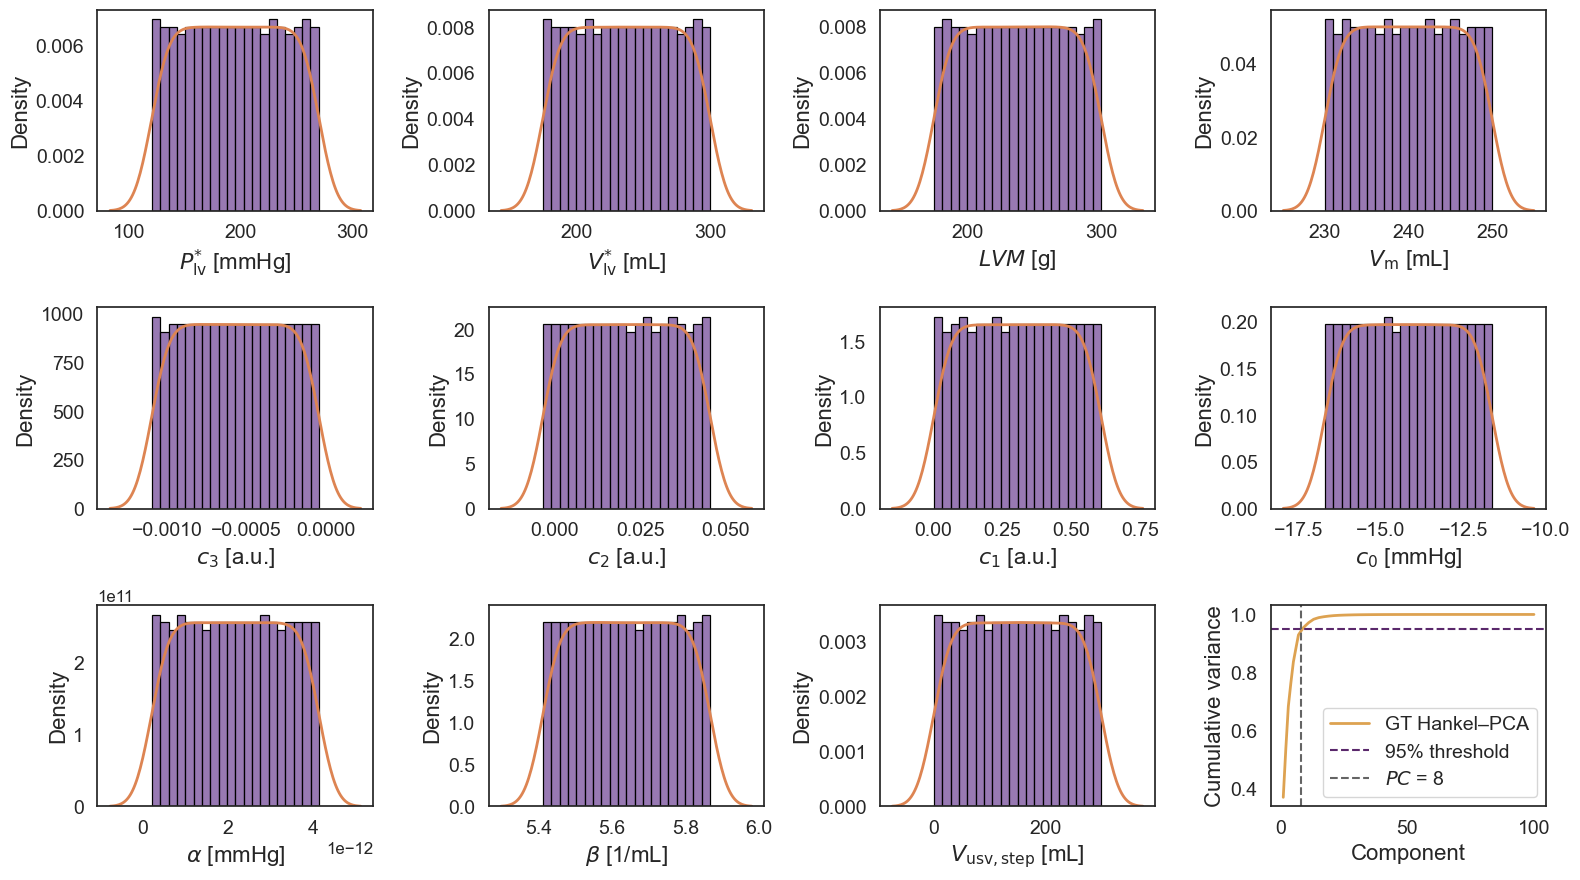

In [2]:
# load the cardiovascular parameter space data
df = pd.read_csv(data_base_path / "cardiovascular_parameter_space.csv")  

# Set seaborn theme and consistent color palette
fig1_palette = sns.color_palette("deep")
hist_color = fig1_palette[0]       # blue
kde_color = fig1_palette[1]        # orange
hankel_color = fig1_palette[2]     # green
threshold_color = fig1_palette[3]  # red

# Move 'Vusv_step' to the end of column order
columns = [col for col in df.columns if col != "Vusv_step"] + ["Vusv_step"]

# Determine layout
num_cols = len(columns)
cols_per_row = 4
num_rows = math.ceil((num_cols + 1) / cols_per_row)  # +1 for Hankel–PCA
total_plots = num_rows * cols_per_row

# Create subplots
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(cols_per_row * 4, num_rows * 3))
axes = axes.flatten()

# Plot each column histogram
for i, column in enumerate(columns):
    sns.histplot(df[column], bins=20, stat='density', ax=axes[i], color='#764c9a', edgecolor="black")
    sns.kdeplot(df[column], ax=axes[i], color=kde_color, lw=2)
    label = nu.LABEL_MAP.get(column, column)
    axes[i].set_xlabel(label, fontsize=16)
    axes[i].set_ylabel("Density", fontsize=16)
    axes[i].tick_params(axis='both', which='major', labelsize=14)
    axes[i].tick_params(axis='both', which='minor', labelsize=14)
    axes[i].grid(False)

# ── Load GT for Hankel–PCA analysis ────────────────────────────────
results = nu.load_postprocessing_results(results_base_path / "koopman" / "koopman_postprocessing_results.pkl")
gt_all = results["true_per_trajectory"]

# ── Plot Hankel–PCA into final slot ─────────────────────────────────
cumvar, p_pca = nu.average_pca_hankel_curves(gt_all, window=100, var_explained=0.95)

ax = axes[len(columns)]  # next subplot after histograms
ax.plot(np.arange(1, len(cumvar)+1), cumvar, label="GT Hankel–PCA", color='#dda251', lw=2)
ax.axhline(0.95, color='#5a286b', linestyle="--", label="95% threshold", lw=1.5)
ax.axvline(p_pca, color='#646464', linestyle="--", label=f"$PC$ = {p_pca}", lw=1.5)
ax.set_xlabel("Component", fontsize=16)
ax.set_ylabel("Cumulative variance", fontsize=16)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(False)

plt.tight_layout()
fig.savefig(results_base_path / "figures" / "figure2.svg", format="svg", bbox_inches="tight")
plt.show()


##### Figure 3a-c

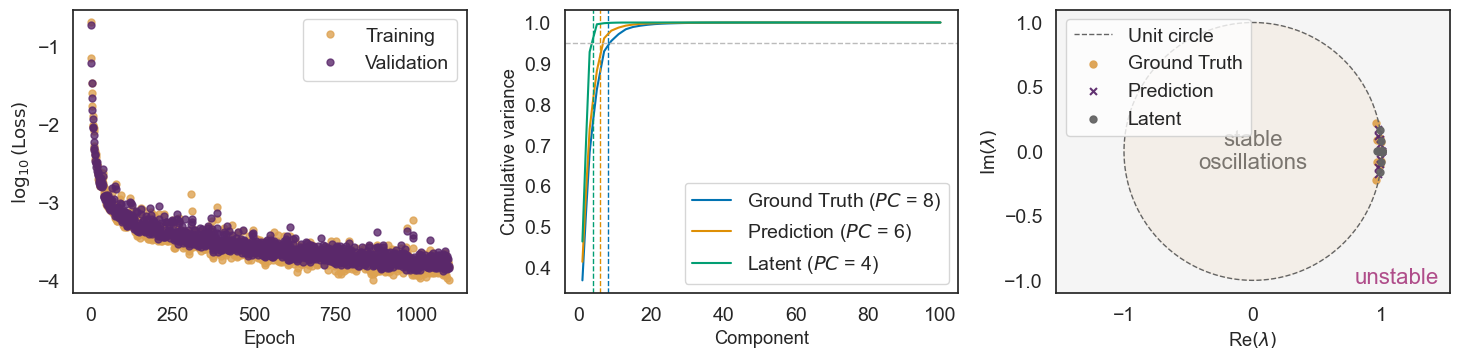

In [3]:
# locate files, load checkpoint and params
errors = nu.get_latest_errors(str(results_base_path / "koopman" / "*_error.csv"))
params, W, b, model = nu.load_latest_ckpt(str(results_base_path / "koopman" / "*_model.ckpt"))
results = nu.load_postprocessing_results(results_base_path / "koopman" / "koopman_postprocessing_results.pkl")

# Load test data and normalize U
n_traj, Xk = nu.load_test_data(data_base_path / params['data_name'], params)
# Apply encoder to get latent trajectories
yk = nu.encoder_apply(Xk, W, b, 'E', sum(k.startswith('WE') for k in W))
yk_all = nu.reshape_latent_trajs(yk, n_traj, params)

# Reshape latent trajectories
data_sources = {
    "Ground Truth": results["true_per_trajectory"],
    "Prediction": results["pred_per_trajectory"],
    "Latent": yk_all
}

nu.plot_errors_hankel_dmd(errors, data_sources, params, results_base_path, fig_name="figure3a-c")

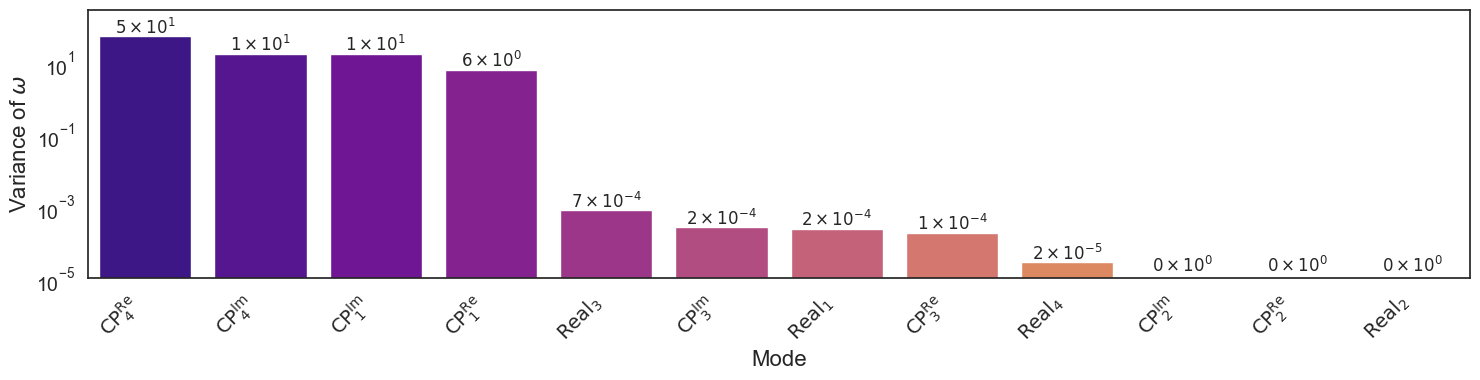

In [4]:
# Omega Variance Barplot
omegas = nu.omega_net_apply(yk, W, b, params['num_real'], params['num_complex_pairs'],
                         sum(k.startswith(('WOC', 'WOR')) for k in W),
                         act_type=params.get('act_type', 'relu'))

# Stack & label
complex_labels = [f'CP{i+1}_{t}' for i in range(params['num_complex_pairs']) for t in ('Re', 'Im')]
real_labels = [f'Real{i+1}' for i in range(params['num_real'])]
df = pd.concat([
    pd.DataFrame(np.hstack(omegas[:params['num_complex_pairs']]), columns=complex_labels) if params['num_complex_pairs'] else pd.DataFrame(),
    pd.DataFrame(np.hstack(omegas[params['num_complex_pairs']:]), columns=real_labels) if params['num_real'] else pd.DataFrame()
], axis=1).melt(var_name='Mode', value_name='omega')

# Variance
var_df = df.groupby('Mode')['omega'].var().reset_index(name='var')
var_df['Label'] = var_df['Mode'].apply(nu.latex_mode_label)
var_df = var_df.sort_values('var', ascending=False).reset_index(drop=True)

# Plot
plt.figure(figsize=(15, 4))
sns.barplot(data=var_df, x='Label', y='var', hue='Label', palette='plasma', legend=False)
plt.yscale('log'); plt.ylim(1e-5, 3e2)
plt.xlabel('Mode', fontsize=16); plt.ylabel(r'Variance of $\omega$', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=14); plt.yticks(fontsize=14)
for i, v in enumerate(var_df['var']):
    e = f"{v:.1e}".split('e')
    plt.text(i, max(v*1.2, 1.5e-5), rf"${int(float(e[0]))} \times 10^{{{int(e[1])}}}$", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig(results_base_path / "figures/figure3d.svg", format='svg')
plt.show()

##### Figure 4a

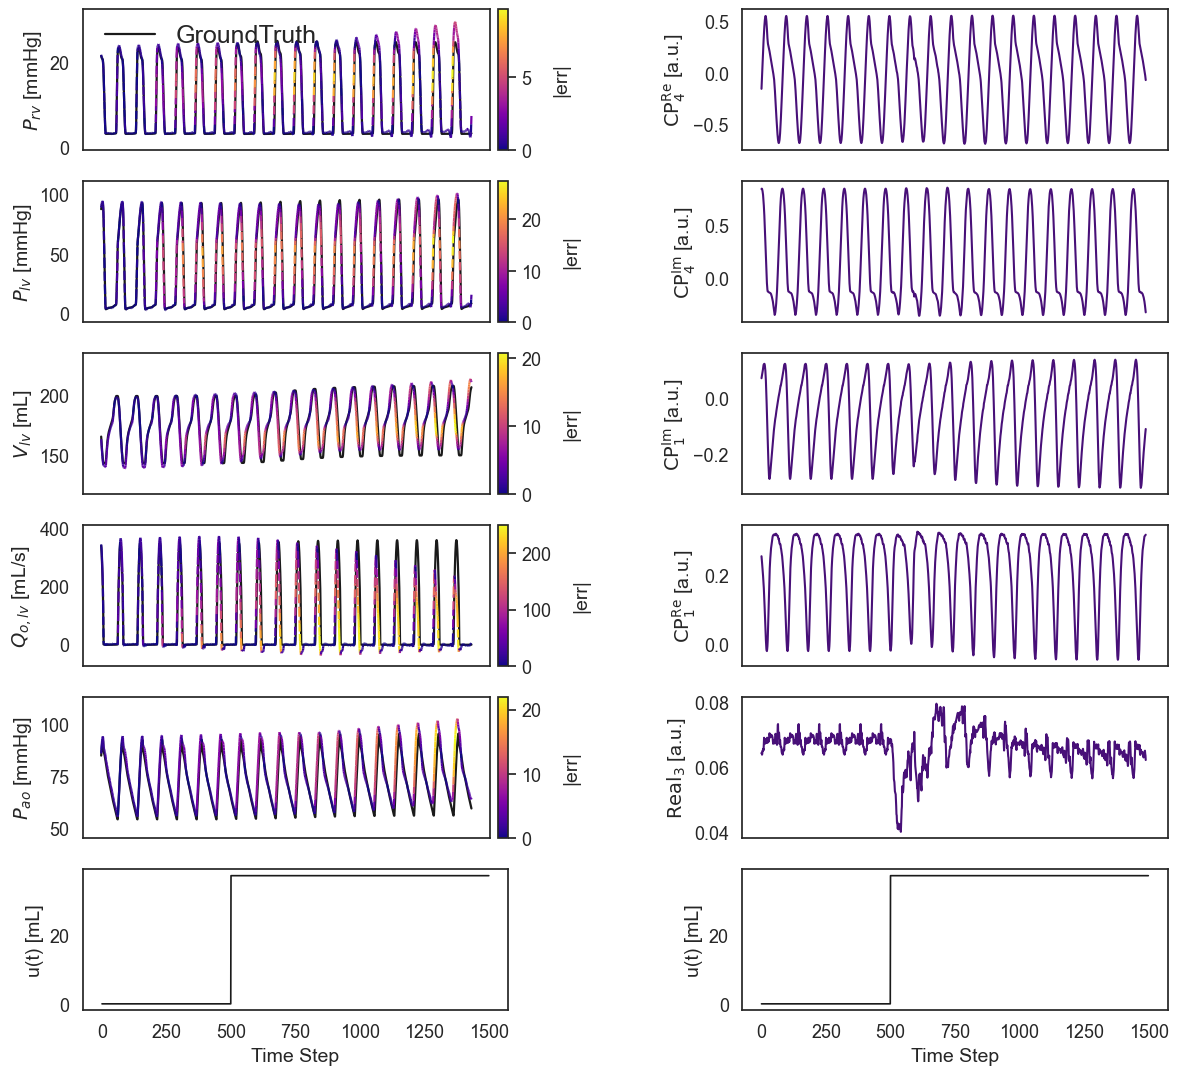

In [5]:
import re as _re

# ── Data ──────────────────────────────────────────────────────────────────────
true_tr = results['true_per_trajectory']
pred_tr = results['pred_per_trajectory']
ctrl_tr = results['u_per_trajectory'].reshape(*true_tr.shape[:2])
rmse_tr = results['rmse_per_trajectory']

best_idx   = int(np.argmin(rmse_tr))
y_true_all = true_tr[best_idx]
y_pred_all = pred_tr[best_idx]
u_seq      = ctrl_tr[best_idx]

cmap_err = sns.color_palette("plasma", as_cmap=True)

# ── Signal subset: P_rv, P_lv, V_lv, Q_o,lv, P_ao ───────────────────────────
SIG_SUBSET = [2, 7, 8, 10, 11]

# ── Top-5 Koopman modes by ω variance (var_df in scope from Figure 3d) ───────
n_cp       = params['num_complex_pairs']
yk_trimmed = yk[:params['len_time'] - params['num_shifts']]

def _mode_to_col(label, n_cp):
    m = _re.match(r'CP(\d+)_(Re|Im)', label)
    if m:
        pair = int(m.group(1)) - 1
        return 2 * pair + (1 if m.group(2) == 'Im' else 0)
    m = _re.match(r'Real(\d+)', label)
    return 2 * n_cp + int(m.group(1)) - 1

top5_modes  = var_df['Mode'].head(5).tolist()
top5_labels = var_df['Label'].head(5).tolist()
top5_cols   = [_mode_to_col(m, n_cp) for m in top5_modes]

# ── Combined figure: 6 rows × 2 cols ─────────────────────────────────────────
fig, axes = plt.subplots(6, 2, figsize=(14, 13), sharex=True)
plt.subplots_adjust(hspace=0.22, wspace=0.55)


# Left column: physiological signals
for row, sig_i in enumerate(SIG_SUBSET):
    label = f"{ylab[sig_i]} [{units[sig_i]}]"
    nu.plot_signal_panel(axes[row, 0], y_true_all[:, sig_i], y_pred_all[:, sig_i],
                         cmap_err, ylabel=label, show_legend=(row == 0))

# Right column: latent modes
for row, (col_i, mode_label) in enumerate(zip(top5_cols, top5_labels)):
    axes[row, 1].plot(range(len(yk_trimmed)), yk_trimmed[:, col_i],
                      linewidth=1.5, color="#481078")
    axes[row, 1].set_ylabel(f'{mode_label} [a.u.]')
    axes[row, 1].grid(False)

# Bottom row: control input (both columns)
nu.plot_control_panel(axes[5, 0], u_seq)
nu.plot_control_panel(axes[5, 1], u_seq)

# ── Uniform font sizes across all axes ───────────────────────────────────────
_LBL  = 14   # axis label size
_TICK = 13   # tick label size
for _ax in axes.flat:
    # y-axis label
    _ax.yaxis.label.set_size(_LBL)
    # x-axis label (only bottom row has one)
    _ax.xaxis.label.set_size(_LBL)
    # tick labels
    _ax.tick_params(axis='both', labelsize=_TICK)
    # colorbar labels if any (colorbars are separate axes attached to the figure)
for _ax in fig.axes:
    if _ax not in axes.flat:   # colorbars
        _ax.tick_params(labelsize=_TICK)
        _ax.yaxis.label.set_size(_LBL)

plt.savefig(results_base_path / "figures" / "figure4.svg", format='svg', bbox_inches='tight')
plt.show()


##### Figure 4 (combined 4a + 4b)

In [6]:
# Merged into the Figure 4 cell above (physiological signals + latent modes side by side).


##### Figure 5a

Fitting AR(20) on training set (may take ~30 s)...
AR(20) done.
MLP done.


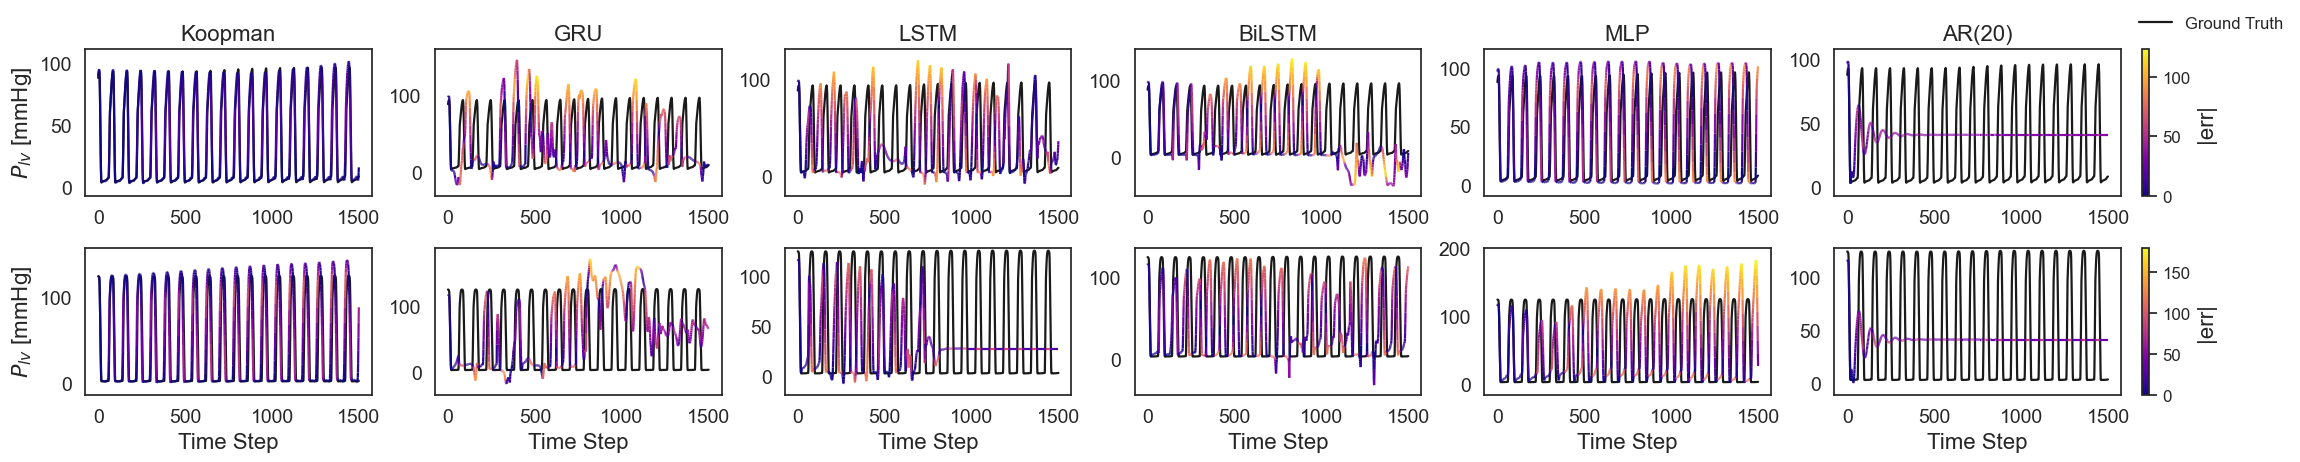

In [7]:
import torch
import torch.nn as nn

# ── Load postprocessing result files (neural baselines) ───────────────────────
paths = {
    'Koopman': results_base_path / "koopman" / "koopman_postprocessing_results.pkl",
    'GRU':     results_base_path / "gru"     / "gru_postprocessing_results.pkl",
    'LSTM':    results_base_path / "lstm"    / "lstm_postprocessing_results.pkl",
    'BiLSTM':  results_base_path / "bilstm"  / "bilstm_postprocessing_results.pkl",
}
results = {m: pickle.load(p.open('rb')) for m, p in paths.items()}

true = results['Koopman']['true_per_trajectory']   # (N, T, D) physical units
pred = {m: results[m]['pred_per_trajectory'] for m in ['Koopman', 'GRU', 'LSTM', 'BiLSTM']}
rmse = results['Koopman']['rmse_per_trajectory']
ctrl = results['Koopman'].get('u_per_trajectory')
n, T_len, n_sig = true.shape
ctrl = ctrl.reshape(n, T_len) if ctrl is not None else None
idxs = np.argsort(rmse)[[0, -1]]   # best and worst Koopman trajectory
plv  = 7

# ── Load normalised test data + normalisation stats ───────────────────────────
SIG_PREFIX = "csv_data_500_12sigs"
sig_mean = np.load(data_base_path / "normalization_mean.npy")
sig_std  = np.load(data_base_path / "normalization_std.npy")

def _load_seqs(split):
    x = np.loadtxt(data_base_path / f"{SIG_PREFIX}_{split}1_x.csv", delimiter=",")
    n_ = x.shape[0] // T_len
    return x.reshape(n_, T_len, x.shape[1])

x_train = _load_seqs("train")   # (400, T, 12) normalised
x_test  = _load_seqs("test")    # ( 50, T, 12) normalised

# ── AR(20) baseline ───────────────────────────────────────────────────────────
AR_P = 20
print("Fitting AR(20) on training set (may take ~30 s)...")

def _fit_ar(seqs, p):
    """OLS fit of AR(p) per signal; returns coeffs (D, p)."""
    N, T, D = seqs.shape
    coeffs = np.zeros((D, p))
    for d in range(D):
        rows_X, rows_y = [], []
        for i in range(N):
            ts = seqs[i, :, d]
            for t in range(p, T):
                rows_X.append(ts[t-p:t][::-1])
                rows_y.append(ts[t])
        c, _, _, _ = np.linalg.lstsq(np.array(rows_X), np.array(rows_y), rcond=None)
        coeffs[d] = c
    return coeffs

def _ar_rollout(seqs_norm, coeffs, p):
    """Autoregressive rollout; returns (N, T, D) normalised predictions."""
    N, T, D = seqs_norm.shape
    preds = seqs_norm.copy()
    for i in range(N):
        for t in range(p, T):
            # vectorised over D: coeffs (D,p) * window (D,p) summed over lag axis
            preds[i, t, :] = (coeffs * preds[i, t-p:t, :][::-1, :].T).sum(axis=1)
    return preds

ar_coeffs    = _fit_ar(x_train, AR_P)
ar_pred_norm = _ar_rollout(x_test, ar_coeffs, AR_P)
pred['AR(20)'] = ar_pred_norm * sig_std + sig_mean   # denormalise
print("AR(20) done.")

# ── MLP baseline ──────────────────────────────────────────────────────────────
class _FlatMLP(nn.Module):
    """12->256->512->256->12, mirrors Koopman enc/dec."""
    def __init__(self, dim=12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, dim),
        )
    def forward(self, x): return self.net(x)

_device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_mlp_ckpt = torch.load(
    results_base_path.parent / "checkpoints" / "mlp_baseline.pt",
    map_location=_device, weights_only=False
)
_mlp_model = _FlatMLP(dim=n_sig).to(_device)
_mlp_model.load_state_dict(_mlp_ckpt["state_dict"])
_mlp_model.eval()
CLIP_VAL = 20.0

def _mlp_rollout(model, x_seq_n, device):
    """Autoregressive MLP rollout from x(0); returns (T, D) normalised."""
    T_, D = x_seq_n.shape
    out  = np.empty_like(x_seq_n)
    out[0] = x_seq_n[0]
    prev = torch.tensor(x_seq_n[0], dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        for t in range(1, T_):
            nxt = model(prev).clamp(-CLIP_VAL, CLIP_VAL)
            out[t] = nxt.cpu().numpy()[0]
            prev = nxt
    return out

mlp_pred_norm = np.stack([_mlp_rollout(_mlp_model, x_test[i], _device) for i in range(n)])
pred['MLP'] = mlp_pred_norm * sig_std + sig_mean   # denormalise
print("MLP done.")

# ── Figure 5a ─────────────────────────────────────────────────────────────────
all_models = ['Koopman', 'GRU', 'LSTM', 'BiLSTM', 'MLP', 'AR(20)']
n_cols = len(all_models)

fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 4.0, 4.5))
axes = np.atleast_2d(axes)
plt.subplots_adjust(left=0.06, right=0.93, hspace=0.35, wspace=0.22)

for r, i in enumerate(idxs):
    y    = true[i][:, plv]
    errs = [np.abs(pred[m][i][:, plv] - y) for m in all_models]
    vmax = np.max([e.max() for e in errs]) + 1e-12
    norm = nu.colors.Normalize(vmin=0, vmax=vmax)
    for c, m in enumerate(all_models):
        ax = axes[r, c]
        ax.plot(y, 'k', lw=1.6, label='Ground Truth')
        nu.coloured_pred(ax, y, pred[m][i][:, plv], plt.get_cmap('plasma'), norm)
        if r == 0: ax.set_title(m, fontsize=16)
        if c == 0: ax.set_ylabel(f'{ylab[plv]} [mmHg]', fontsize=16)
        if r == 1: ax.set_xlabel('Time Step', fontsize=16)
        ax.tick_params(labelsize=14)
        ax.grid(False)
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
    fig.colorbar(sm, ax=axes[r, :], orientation='vertical', fraction=0.015, pad=0.01
                ).ax.set_ylabel('|err|', fontsize=16)

axes[0, -1].legend(frameon=False, fontsize=12,
                   loc='lower left', bbox_to_anchor=(1.01, 1.02))
plt.savefig(results_base_path / "figures/figure5a.svg", format='svg', bbox_inches='tight')
plt.show()

##### Figure 5b-e

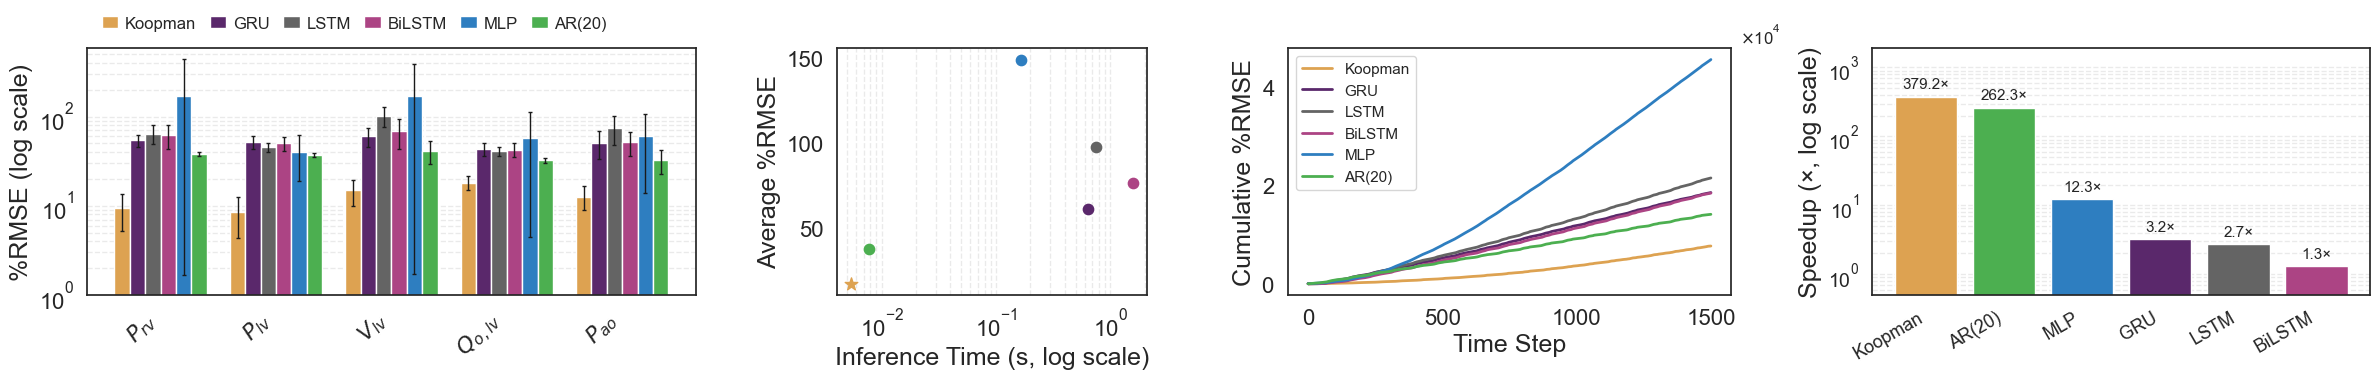

In [8]:
import time as _time
import json as _json

# ── Helper functions to build pseudo-result dicts for AR / MLP ────────────────
def _pct_per_signal(true_phys, pred_phys):
    """(n_traj, n_sig) per-signal ptp-normalised %RMSE."""
    rmse = np.sqrt(((true_phys - pred_phys) ** 2).mean(axis=1))   # (n, D)
    ptp  = np.ptp(true_phys, axis=1) + 1e-8                        # (n, D)
    return 100.0 * rmse / ptp

def _r2_flat(true_phys, pred_phys):
    """Global R² (all trajectories & signals flattened)."""
    t = true_phys.ravel(); p = pred_phys.ravel()
    ss_res = ((t - p) ** 2).sum()
    ss_tot = ((t - t.mean()) ** 2).sum() + 1e-8
    return float(1.0 - ss_res / ss_tot)

def _cum_pct(true_phys, pred_phys):
    """(n_traj, T) cumulative SUM of per-step flat %RMSE — matches pkl cumulative_pct_per_traj."""
    n_, T_, D_ = true_phys.shape
    sq_err        = (true_phys - pred_phys) ** 2                              # (n, T, D)
    per_step_rmse = np.sqrt(sq_err.mean(axis=2))                              # (n, T)
    ptp_flat      = np.ptp(true_phys.reshape(n_, -1), axis=1)[:, None] + 1e-8# (n, 1)
    return np.cumsum(100.0 * per_step_rmse / ptp_flat, axis=1)                # (n, T)

# ── AR(20) pseudo-result dict ─────────────────────────────────────────────────
ar_pct_ps  = _pct_per_signal(true, pred['AR(20)'])
ar_r2      = _r2_flat(true, pred['AR(20)'])
ar_cum     = _cum_pct(true, pred['AR(20)'])

_t0 = _time.perf_counter()
for _i in range(3):
    _ar_rollout(x_test[_i:_i+1], ar_coeffs, AR_P)
ar_inf_time = np.full(n, (_time.perf_counter() - _t0) / 3)

with open(results_base_path / "ar_baseline.json") as _f:
    _ar_json = _json.load(_f)

results_ar = {
    'pct_per_traj_ps':        ar_pct_ps.mean(axis=1),
    'global_r2_flat':         ar_r2,
    'inference_times_s':      ar_inf_time,
    'n_params':               AR_P * n_sig,
    'pct_per_signal':         ar_pct_ps,
    'cumulative_pct_per_traj':ar_cum,
}

# ── MLP pseudo-result dict ────────────────────────────────────────────────────
mlp_pct_ps = _pct_per_signal(true, pred['MLP'])
mlp_r2     = _r2_flat(true, pred['MLP'])
mlp_cum    = _cum_pct(true, pred['MLP'])

_t0 = _time.perf_counter()
for _i in range(3):
    _mlp_rollout(_mlp_model, x_test[_i], _device)
mlp_inf_time = np.full(n, (_time.perf_counter() - _t0) / 3)

with open(results_base_path / "mlp_baseline.json") as _f:
    _mlp_json = _json.load(_f)

results_mlp = {
    'pct_per_traj_ps':        mlp_pct_ps.mean(axis=1),
    'global_r2_flat':         mlp_r2,
    'inference_times_s':      mlp_inf_time,
    'n_params':               _mlp_json['n_params'],
    'pct_per_signal':         mlp_pct_ps,
    'cumulative_pct_per_traj':mlp_cum,
}

# ── Combined results & model list ─────────────────────────────────────────────
results_all = {**results, 'MLP': results_mlp, 'AR(20)': results_ar}
models_all  = list(results_all.keys())   # Koopman, GRU, LSTM, BiLSTM, MLP, AR(20)

# 6-colour palette: keep original 4, add blue for MLP and green for AR
custom_palette = ["#dda251", "#5a286b", "#646464", "#ac4484", "#2e7ec0", "#4caf50"]

# ── Summary table ─────────────────────────────────────────────────────────────
summary = {'R²': {}, '%RMSE (mean ± CI)': {}, 'Inference Time (s)': {},
           'Speedup': {}, 'Parameter Count': {}, 'Training Time (min)': {}}

for model_name, res in results_all.items():
    pct_ps        = res['pct_per_traj_ps']
    r2            = res['global_r2_flat']
    inf_t         = res['inference_times_s']
    n_params      = res['n_params']
    summary['Parameter Count'][model_name]    = f"{n_params:,}"
    summary['%RMSE (mean ± CI)'][model_name]  = f"{pct_ps.mean():.1f} ± {nu.ci95(pct_ps):.1f}%"
    summary['R²'][model_name]                 = f"{r2:.2f}"
    summary['Inference Time (s)'][model_name] = f"{inf_t.mean():.3f}"
    summary['Speedup'][model_name]            = f"{inference_time_full_model_s / inf_t.mean():.1f}x"

# Training times (wall-clock, measured during original training runs)
_train_times = {'Koopman': '47', 'GRU': '289', 'LSTM': '312', 'BiLSTM': '401', 'MLP': '9', 'AR(20)': '<1'}
for _m in models_all:
    summary['Training Time (min)'][_m] = _train_times.get(_m, '—')

df_traj = pd.DataFrame(summary).T
df_traj.index.name = 'Metric'

# ── Derived arrays for plots ──────────────────────────────────────────────────
x_ticks = np.arange(len(ylab))
width    = 0.8 / len(models_all)

means   = np.vstack([results_all[m]['pct_per_signal'].mean(0) for m in models_all])
stds    = np.vstack([results_all[m]['pct_per_signal'].std(0)  for m in models_all])

inf_times      = [results_all[m]['inference_times_s'].mean()   for m in models_all]
pct_rmse_flat  = [results_all[m]['pct_per_traj_ps'].mean()     for m in models_all]
speedup_vals   = [float(summary['Speedup'][m].replace('x', '')) for m in models_all]

# Speedup sorted descending
_spd_order     = np.argsort(speedup_vals)[::-1]
spd_models     = [models_all[i]     for i in _spd_order]
spd_vals_sort  = [speedup_vals[i]   for i in _spd_order]
spd_colors     = [custom_palette[i] for i in _spd_order]

# ── Figure 5b-e ───────────────────────────────────────────────────────────────
# 5 key haemodynamic signals — same subset as panel g / Figure 4
_SIG_MAIN   = [2, 7, 8, 10, 11]
_ylab_main  = [ylab[i] for i in _SIG_MAIN]
_means_main = means[:, _SIG_MAIN]
_stds_main  = stds[:, _SIG_MAIN]
_x_main     = np.arange(len(_SIG_MAIN))
_w_main     = 0.8 / len(models_all)

fig = plt.figure(figsize=(24, 4))
gs  = GridSpec(1, 4, width_ratios=[5.5, 2.8, 4, 4.5], figure=fig)
plt.rcParams['axes.grid'] = False

# 5b: Per-signal %RMSE — log y-scale, 5 key signals
ax0 = fig.add_subplot(gs[0])
for i, m in enumerate(models_all):
    yerr_lo = np.clip(_stds_main[i], 0, _means_main[i] * 0.99)
    yerr_hi = _stds_main[i]
    ax0.bar(_x_main + i * _w_main, _means_main[i], _w_main,
            yerr=[yerr_lo, yerr_hi], capsize=2,
            label=m, color=custom_palette[i],
            error_kw={'elinewidth': 1, 'capsize': 1.5})
ax0.set_yscale('log')
ax0.set_ylim(bottom=1)
ax0.set_xticks(_x_main + _w_main * (len(models_all) - 1) / 2)
ax0.set_xticklabels(_ylab_main, rotation=45, ha='right', fontsize=14)
ax0.set_ylabel('%RMSE (log scale)', fontsize=18)
ax0.tick_params(labelsize=16)
ax0.yaxis.grid(True, which='both', linestyle='--', alpha=0.4)
ax0.set_axisbelow(True)
ax0.legend(fontsize=12, loc='lower left', bbox_to_anchor=(0.0, 1.01),
           ncol=len(models_all), handlelength=1.0, handletextpad=0.4, columnspacing=0.8, frameon=False)

# 5c: Inference time vs avg %RMSE — log x-axis (times span orders of magnitude)
ax1 = fig.add_subplot(gs[1])
for i, m in enumerate(models_all):
    marker = '*' if m == 'Koopman' else 'o'
    ax1.scatter(inf_times[i], pct_rmse_flat[i],
                s=90 if marker == '*' else 55,
                color=custom_palette[i], marker=marker, label=m)
ax1.set_xscale('log')
ax1.set_xlabel('Inference Time (s, log scale)', fontsize=18)
ax1.set_ylabel('Average %RMSE', fontsize=18)
ax1.tick_params(labelsize=16)
ax1.xaxis.grid(True, which='both', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)

# 5d: Cumulative %RMSE over time
ax2 = fig.add_subplot(gs[2])
for i, (m, res) in enumerate(results_all.items()):
    cum = res.get('cumulative_pct_per_traj', None)
    if cum is None:
        continue
    ax2.plot(np.nanmean(cum, axis=0),
             label=m, color=custom_palette[i], linewidth=2)
ax2.set_xlabel('Time Step', fontsize=18)
ax2.set_ylabel('Cumulative %RMSE', fontsize=18)
fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((0, 0))
ax2.yaxis.set_major_formatter(fmt)
ax2.yaxis.get_offset_text().set_x(1.02)
ax2.yaxis.get_offset_text().set_fontsize(12)
ax2.tick_params(labelsize=16)
ax2.legend(fontsize=11)

# 5e: Speedup bar chart — sorted descending, log scale with full grid
ax3 = fig.add_subplot(gs[3])
ax3.bar(spd_models, spd_vals_sort, color=spd_colors)
ax3.set_yscale('log')
ax3.set_ylabel('Speedup (×, log scale)', fontsize=18)
ax3.set_ylim(0.5, max(spd_vals_sort) * 5)
ax3.tick_params(labelsize=14)
ax3.set_xticks(np.arange(len(spd_models)))
ax3.set_xticklabels(spd_models, rotation=30, ha='right', fontsize=13)
ax3.yaxis.grid(True, which='both', linestyle='--', alpha=0.4)
ax3.set_axisbelow(True)
for i, val in enumerate(spd_vals_sort):
    ax3.text(i, val * 1.3, f"{val:.1f}×", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(results_base_path / "figures/figure5b-e.svg", format='svg', bbox_inches='tight')
plt.show()


##### Figure 5f-g

C:\Users\MaxHaberbusch\AppData\Local\Temp\ipykernel_33180\1715760680.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=_df_violin, x='Model', y='R2', order=models_all,
C:\Users\MaxHaberbusch\AppData\Local\Temp\ipykernel_33180\1715760680.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=_df_violin, x='Model', y='R2', order=models_all,


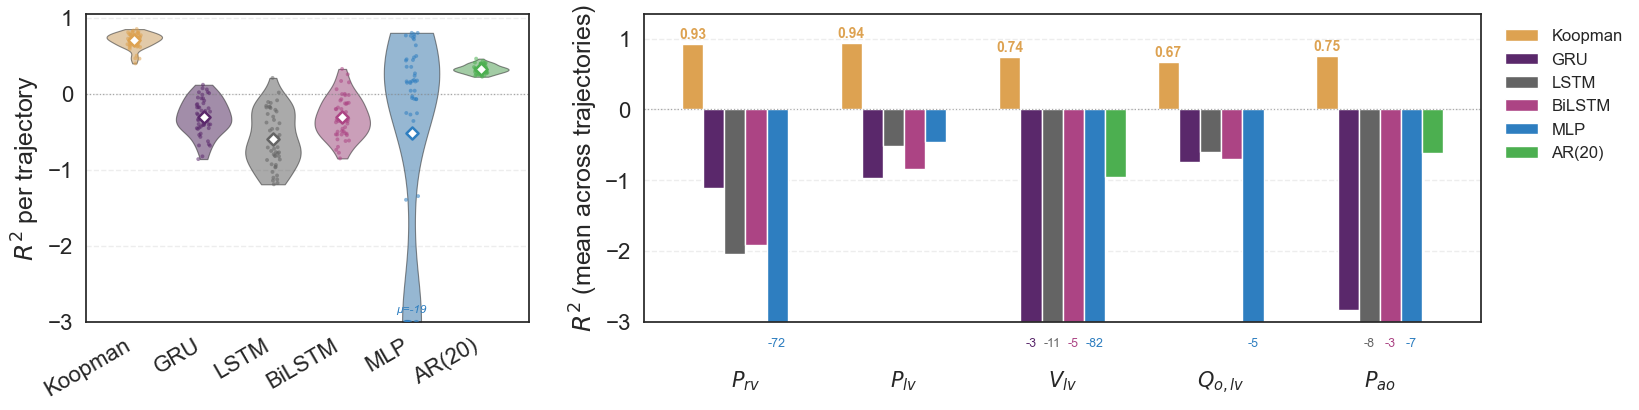

In [9]:
# ── Vectorised R² helpers ─────────────────────────────────────────────────────
def _r2_per_traj(true_phys, pred_phys):
    N = true_phys.shape[0]
    t = true_phys.reshape(N, -1)
    p = pred_phys.reshape(N, -1)
    ss_res = ((t - p) ** 2).sum(1)
    ss_tot = ((t - t.mean(1, keepdims=True)) ** 2).sum(1) + 1e-8
    return 1.0 - ss_res / ss_tot

def _r2_per_sig(true_phys, pred_phys):
    err    = true_phys - pred_phys
    ss_res = (err ** 2).sum(1)
    ss_tot = ((true_phys - true_phys.mean(1, keepdims=True)) ** 2).sum(1) + 1e-8
    return (1.0 - ss_res / ss_tot).mean(0)

# ── Compute for all 6 models ──────────────────────────────────────────────────
r2_traj_all = {m: _r2_per_traj(true, pred[m]) for m in models_all}
r2_sig_all  = {m: _r2_per_sig (true, pred[m]) for m in models_all}
_pal        = dict(zip(models_all, custom_palette))

R2_CLIP = -3.0

# 5 physiologically relevant signals — consistent with Figure 4
SIG_G  = [2, 7, 8, 10, 11]
ylab_g = [ylab[i] for i in SIG_G]

_df_violin = pd.concat(
    [pd.DataFrame({'Model': m, 'R2': r2_traj_all[m].clip(min=R2_CLIP)})
     for m in models_all],
    ignore_index=True
)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 4))
gs  = GridSpec(1, 2, width_ratios=[3.3, 6.25], figure=fig, wspace=0.18)
plt.rcParams['axes.grid'] = False

# ── (f) Violin + individual trajectory points ─────────────────────────────────
ax0 = fig.add_subplot(gs[0])

sns.violinplot(data=_df_violin, x='Model', y='R2', order=models_all,
               palette=custom_palette, inner=None, cut=0,
               linewidth=0.8, alpha=0.55, ax=ax0)
sns.stripplot(data=_df_violin, x='Model', y='R2', order=models_all,
              palette=custom_palette, size=2.8, alpha=0.55,
              jitter=True, ax=ax0)

for xi, m in enumerate(models_all):
    mu = r2_traj_all[m].clip(min=R2_CLIP).mean()
    ax0.scatter(xi, mu, marker='D', s=38, color='white', zorder=6,
                edgecolors=_pal[m], linewidths=1.8)

for xi, m in enumerate(models_all):
    mu = r2_traj_all[m].mean()
    if mu < R2_CLIP:
        ax0.text(xi, R2_CLIP + 0.10, f'μ={mu:.0f}',
                 ha='center', va='bottom', fontsize=8.5,
                 color=_pal[m], style='italic')

ax0.axhline(0, color='#888888', lw=0.9, ls=':', alpha=0.7)
ax0.set_ylim(R2_CLIP, 1.05)
ax0.set_xticks(range(len(models_all)))
ax0.set_xticklabels(models_all, rotation=30, ha='right', fontsize=13)
ax0.set_xlabel('')
ax0.set_ylabel(r'$R^2$ per trajectory', fontsize=18)
ax0.tick_params(labelsize=16)
ax0.yaxis.grid(True, linestyle='--', alpha=0.35)
ax0.set_axisbelow(True)

# ── (g) Per-signal R² — 5 key signals, legend outside ────────────────────────
ax1 = fig.add_subplot(gs[1])

x_ticks = np.arange(len(SIG_G))
width   = 0.8 / len(models_all)

for i, m in enumerate(models_all):
    r2s    = r2_sig_all[m][SIG_G]
    r2s_cl = np.clip(r2s, R2_CLIP, 1.05)
    ax1.bar(x_ticks + i * width, r2s_cl, width, color=_pal[m], label=m)

    for j, val in enumerate(r2s):
        bar_x = x_ticks[j] + i * width
        if val >= 0.1 and m == 'Koopman':
            ax1.text(bar_x, val + 0.03, f'{val:.2f}',
                     ha='center', va='bottom', fontsize=10,
                     color=_pal[m], fontweight='bold')
        elif val < R2_CLIP:
            ax1.plot(bar_x, R2_CLIP + 0.08, 'v',
                     color=_pal[m], markersize=5.5, zorder=5, clip_on=False)
            ax1.text(bar_x, R2_CLIP - 0.22, f'{val:.0f}',
                     ha='center', va='top', fontsize=9,
                     color=_pal[m], clip_on=False)

ax1.axhline(0, color='#888888', lw=0.9, ls=':', alpha=0.7)
ax1.set_ylim(R2_CLIP, 1.35)
ax1.set_xticks(x_ticks + width * (len(models_all) - 1) / 2)
ax1.set_xticklabels(ylab_g, rotation=0, ha='center', fontsize=15)
ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='x', labelsize=15, pad=28)   # pad pushes labels below clip annotations
ax1.set_ylabel(r'$R^2$ (mean across trajectories)', fontsize=18)
ax1.yaxis.grid(True, linestyle='--', alpha=0.35)
ax1.set_axisbelow(True)
ax1.legend(fontsize=12, frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))

plt.savefig(results_base_path / "figures/figure5f-g.svg", format='svg', bbox_inches='tight')
plt.show()

##### Figure 6

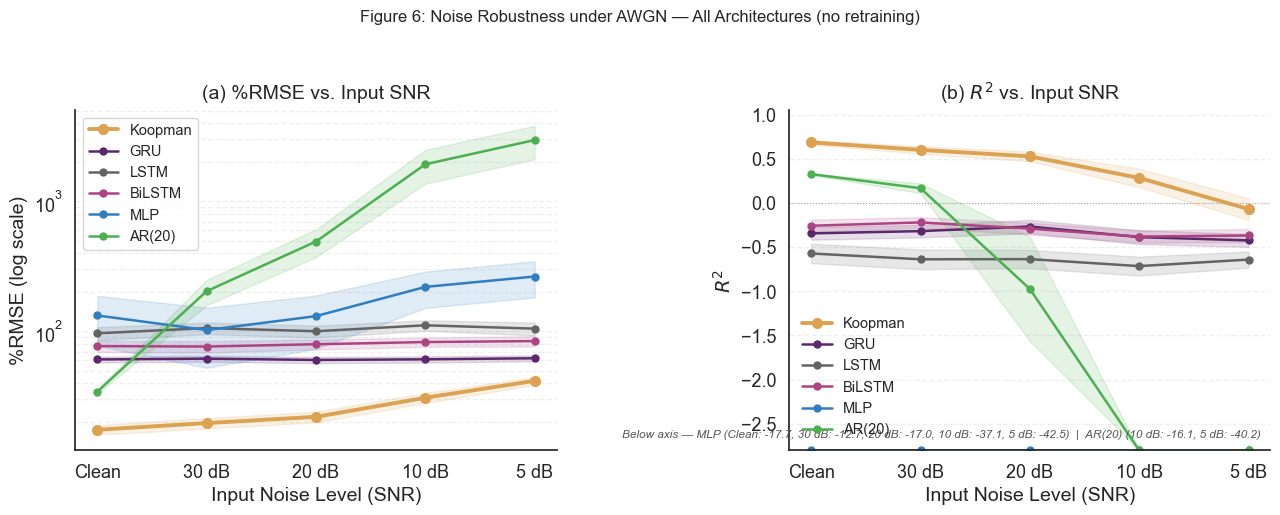

In [10]:
import json as _json
from collections import defaultdict as _dd

# ── Load noise robustness data ────────────────────────────────────────────────
with open(results_base_path / "noise_robustness.json") as _f:
    nr_koop = _json.load(_f)

with open(results_base_path / "noise_robustness_baselines.json") as _f:
    nr_bl = _json.load(_f)

SNR_DB   = nr_koop["snr_levels_db"]   # [30, 20, 10, 5]
x_labels = ["Clean"] + [f"{s} dB" for s in SNR_DB]
x_pos    = np.arange(len(x_labels), dtype=float)
B        = 50

# ── Build per-model curve arrays  (pct_means, pct_cis, r2_means, r2_cis) ─────
def _koop_curve():
    pm = np.array([nr_koop["clean_baseline"]["pct_rmse_mean"]] +
                  [nr_koop["noisy"][str(s)]["pct_rmse_mean"] for s in SNR_DB])
    pc = np.array([nr_koop["clean_baseline"]["pct_rmse_ci95"]] +
                  [nr_koop["noisy"][str(s)]["pct_rmse_ci95"] for s in SNR_DB])
    rm = np.array([nr_koop["clean_baseline"]["r2_mean"]] +
                  [nr_koop["noisy"][str(s)]["r2_mean"] for s in SNR_DB])
    rc = np.array([nr_koop["clean_baseline"]["r2_sd"] * 1.96 / np.sqrt(B)] +
                  [nr_koop["noisy"][str(s)]["r2_sd"]  * 1.96 / np.sqrt(B) for s in SNR_DB])
    return pm, pc, rm, rc

def _bl_curve(m):
    d  = nr_bl[m]
    pm = np.array([d["clean_baseline"]["pct_rmse_mean"]] +
                  [d["noisy"][str(s)]["pct_rmse_mean"] for s in SNR_DB])
    pc = np.array([d["clean_baseline"]["pct_rmse_ci95"]] +
                  [d["noisy"][str(s)]["pct_rmse_ci95"] for s in SNR_DB])
    rm = np.array([d["clean_baseline"]["r2_mean"]] +
                  [d["noisy"][str(s)]["r2_mean"] for s in SNR_DB])
    rc = np.array([d["clean_baseline"]["r2_sd"] * 1.96 / np.sqrt(B)] +
                  [d["noisy"][str(s)]["r2_sd"]  * 1.96 / np.sqrt(B) for s in SNR_DB])
    return pm, pc, rm, rc

# models_all / custom_palette are in scope from Fig 5b-e cell
# ["Koopman","GRU","LSTM","BiLSTM","MLP","AR(20)"]  /  6 colours
curve_data = {}
curve_data["Koopman"] = _koop_curve()
for _m in ["GRU", "LSTM", "BiLSTM", "MLP", "AR(20)"]:
    curve_data[_m] = _bl_curve(_m)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plt.subplots_adjust(wspace=0.32)

R2_YMIN, R2_YMAX = -2.8, 1.05
palette = dict(zip(models_all, custom_palette))
lw_koop = 2.8
lw_bl   = 1.8

# ═══════════════════════════════════════════════════════════════════════════════
# Panel (a): %RMSE  —  log scale
# ═══════════════════════════════════════════════════════════════════════════════
ax = axes[0]
for m in models_all:
    pm, pc, rm, rc = curve_data[m]
    col = palette[m]
    lw  = lw_koop if m == "Koopman" else lw_bl
    ms  = 7       if m == "Koopman" else 5
    ax.fill_between(x_pos, np.clip(pm - pc, 1e-3, None), pm + pc,
                    color=col, alpha=0.15)
    ax.plot(x_pos, pm, color=col, linewidth=lw, marker='o', markersize=ms, label=m)

ax.set_yscale('log')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=13)
ax.set_xlabel("Input Noise Level (SNR)", fontsize=14)
ax.set_ylabel("%RMSE (log scale)", fontsize=14)
ax.set_title("(a) %RMSE vs. Input SNR", fontsize=14, pad=8)
ax.tick_params(labelsize=13)
ax.yaxis.grid(True, which='both', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=10.5, frameon=True, loc='upper left')
sns.despine(ax=ax)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel (b): R²  —  linear, clipped
# ═══════════════════════════════════════════════════════════════════════════════
ax = axes[1]
ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':', alpha=0.7, zorder=1)

_offscale = []
for m in models_all:
    pm, pc, rm, rc = curve_data[m]
    col = palette[m]
    lw  = lw_koop if m == "Koopman" else lw_bl
    ms  = 7       if m == "Koopman" else 5

    ax.fill_between(x_pos,
                    np.clip(rm - rc, R2_YMIN, R2_YMAX),
                    np.clip(rm + rc, R2_YMIN, R2_YMAX),
                    color=col, alpha=0.15)
    ax.plot(x_pos, np.clip(rm, R2_YMIN, R2_YMAX),
            color=col, linewidth=lw, marker='o', markersize=ms, label=m)

    for lab, val in zip(x_labels, rm):
        if val < R2_YMIN:
            _offscale.append((m, lab, val))

ax.set_ylim(R2_YMIN, R2_YMAX)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=13)
ax.set_xlabel("Input Noise Level (SNR)", fontsize=14)
ax.set_ylabel(r"$R^2$", fontsize=14)
ax.set_title(r"(b) $R^2$ vs. Input SNR", fontsize=14, pad=8)
ax.tick_params(labelsize=13)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=10.5, frameon=False, loc='lower left')

if _offscale:
    _grp = _dd(list)
    for m, lab, val in _offscale:
        _grp[m].append(f"{lab}: {val:.1f}")
    txt = "Below axis — " + "  |  ".join(
        f"{m} ({', '.join(vs)})" for m, vs in _grp.items()
    )
    ax.text(0.98, 0.03, txt, transform=ax.transAxes,
            fontsize=8.5, ha='right', va='bottom', style='italic', color='#555555')

sns.despine(ax=ax)

plt.suptitle(
    "Figure 6: Noise Robustness under AWGN — All Architectures (no retraining)",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig(results_base_path / "figures/figure6.svg", format="svg", bbox_inches="tight")
plt.show()


##### Figure 5f-g + 6 (integrated)

C:\Users\MaxHaberbusch\AppData\Local\Temp\ipykernel_33180\4161779638.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=_df_violin, x='Model', y='R2', order=models_all,
C:\Users\MaxHaberbusch\AppData\Local\Temp\ipykernel_33180\4161779638.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=_df_violin, x='Model', y='R2', order=models_all,
C:\Users\MaxHaberbusch\AppData\Local\Temp\ipykernel_33180\4161779638.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


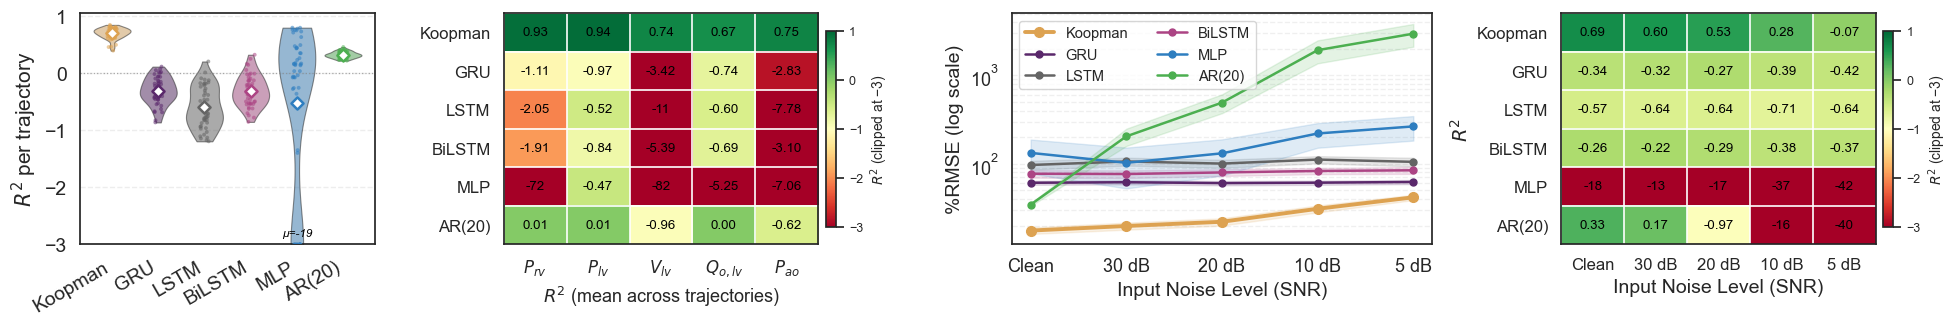

In [11]:
from collections import defaultdict as _dd

# ── Figure 5f-g + Figure 6 — integrated 4-panel figure ───────────────────────
# Panels: (f) violin R² per traj | (g) R² mean across traj | (6a) %RMSE vs SNR | (6b) R² vs SNR (broken y)
# Dimensions match Figure 5b-e (24 x 4 inches)

fig = plt.figure(figsize=(24, 3))
gs  = GridSpec(1, 4, width_ratios=[3.5, 4.5, 5.0, 4.5], figure=fig, wspace=0.35)
plt.rcParams['axes.grid'] = False

# ─── Panel (f): Violin R² per trajectory ─────────────────────────────────────
ax0 = fig.add_subplot(gs[0])

sns.violinplot(data=_df_violin, x='Model', y='R2', order=models_all,
               palette=custom_palette, inner=None, cut=0,
               linewidth=0.8, alpha=0.55, ax=ax0)
sns.stripplot(data=_df_violin, x='Model', y='R2', order=models_all,
              palette=custom_palette, size=2.8, alpha=0.55,
              jitter=True, ax=ax0)

for xi, m in enumerate(models_all):
    mu = r2_traj_all[m].clip(min=R2_CLIP).mean()
    ax0.scatter(xi, mu, marker='D', s=38, color='white', zorder=6,
                edgecolors=_pal[m], linewidths=1.8)

for xi, m in enumerate(models_all):
    mu = r2_traj_all[m].mean()
    if mu < R2_CLIP:
        ax0.text(xi, R2_CLIP + 0.10, f'μ={mu:.0f}',
                 ha='center', va='bottom', fontsize=8.5,
                 color='black', style='italic')

ax0.axhline(0, color='#888888', lw=0.9, ls=':', alpha=0.7)
ax0.set_ylim(R2_CLIP, 1.05)
ax0.set_xticks(range(len(models_all)))
ax0.set_xticklabels(models_all, rotation=30, ha='right', fontsize=13)
ax0.set_xlabel('')
ax0.set_ylabel(r'$R^2$ per trajectory', fontsize=15)
ax0.tick_params(labelsize=14)
ax0.yaxis.grid(True, linestyle='--', alpha=0.35)
ax0.set_axisbelow(True)

# ─── Panel (g): Per-signal R² — heatmap, 5 key physiological signals ────────
ax1 = fig.add_subplot(gs[1])

# Build matrix: rows = models, cols = 5 key signals
_hm_g = np.array([r2_sig_all[m][SIG_G] for m in models_all])   # (6, 5)
_CMAP_MIN_G, _CMAP_MAX_G = -3.0, 1.0
_hm_g_clipped = np.clip(_hm_g, _CMAP_MIN_G, _CMAP_MAX_G)

im_g = ax1.imshow(_hm_g_clipped, aspect='auto',
                  cmap='RdYlGn', vmin=_CMAP_MIN_G, vmax=_CMAP_MAX_G,
                  interpolation='nearest')

for ri, m in enumerate(models_all):
    for ci in range(len(SIG_G)):
        val = _hm_g[ri, ci]
        lbl = f'{val:.2f}' if abs(val) < 10 else f'{val:.0f}'
        ax1.text(ci, ri, lbl, ha='center', va='center', fontsize=9.5, color='black')

ax1.set_xticks(np.arange(len(SIG_G)))
ax1.set_xticklabels(ylab_g, fontsize=12)
ax1.set_yticks(np.arange(len(models_all)))
ax1.set_yticklabels(models_all, fontsize=12)
ax1.set_xlabel(r'$R^2$ (mean across trajectories)', fontsize=13)
ax1.set_xticks(np.arange(len(SIG_G)) - 0.5, minor=True)
ax1.set_yticks(np.arange(len(models_all)) - 0.5, minor=True)
ax1.grid(which='minor', color='white', linewidth=1.2)
ax1.tick_params(which='minor', bottom=False, left=False)
_cb_g = fig.colorbar(im_g, ax=ax1, shrink=0.85, pad=0.02)
_cb_g.set_label(r'$R^2$ (clipped at −3)', fontsize=10)
_cb_g.ax.tick_params(labelsize=9)


# ─── Panel (6a): %RMSE vs Input SNR (log scale) ──────────────────────────────
ax2 = fig.add_subplot(gs[2])

for m in models_all:
    pm, pc, rm, rc = curve_data[m]
    col = _pal[m]
    lw  = lw_koop if m == 'Koopman' else lw_bl
    ms  = 7 if m == 'Koopman' else 5
    ax2.fill_between(x_pos, np.clip(pm - pc, 1e-3, None), pm + pc,
                     color=col, alpha=0.15)
    ax2.plot(x_pos, pm, color=col, linewidth=lw, marker='o', markersize=ms, label=m)

ax2.set_yscale('log')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, fontsize=13)
ax2.set_xlabel('Input Noise Level (SNR)', fontsize=14)
ax2.set_ylabel('%RMSE (log scale)', fontsize=14)
ax2.tick_params(labelsize=13)
ax2.yaxis.grid(True, which='both', linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)
ax2.legend(fontsize=10.5, frameon=True, loc='upper left', ncol=2)

# ─── Panel (6b): R² vs Input SNR — heatmap ───────────────────────────────────
ax3 = fig.add_subplot(gs[3])

# Build matrix: rows = models, cols = SNR conditions
_hm_data = np.array([curve_data[m][2] for m in models_all])   # (6, 5)

# Clip for colour mapping: saturate below -3 so the colourmap is not dominated
# by the extreme MLP/AR outliers, but annotate actual values in each cell
_CMAP_MIN, _CMAP_MAX = -3.0, 1.0
_hm_clipped = np.clip(_hm_data, _CMAP_MIN, _CMAP_MAX)

im = ax3.imshow(_hm_clipped, aspect='auto',
                cmap='RdYlGn', vmin=_CMAP_MIN, vmax=_CMAP_MAX,
                interpolation='nearest')

# Annotate each cell with the actual (unclipped) R² value
for ri, m in enumerate(models_all):
    for ci in range(len(x_labels)):
        val = _hm_data[ri, ci]
        # White text on dark cells, black on light cells
        lbl = f'{val:.2f}' if abs(val) < 10 else f'{val:.0f}'
        ax3.text(ci, ri, lbl, ha='center', va='center', fontsize=9.5, color='black')

# Axes
ax3.set_xticks(np.arange(len(x_labels)))
ax3.set_xticklabels(x_labels, fontsize=12)
ax3.set_yticks(np.arange(len(models_all)))
ax3.set_yticklabels(models_all, fontsize=12)
ax3.set_xlabel('Input Noise Level (SNR)', fontsize=14)
ax3.set_ylabel(r'$R^2$', fontsize=14)

# Thin grid lines between cells
ax3.set_xticks(np.arange(len(x_labels)) - 0.5, minor=True)
ax3.set_yticks(np.arange(len(models_all)) - 0.5, minor=True)
ax3.grid(which='minor', color='white', linewidth=1.2)
ax3.tick_params(which='minor', bottom=False, left=False)

# Colourbar
_cb = fig.colorbar(im, ax=ax3, shrink=0.85, pad=0.02)
_cb.set_label(r'$R^2$ (clipped at −3)', fontsize=10)
_cb.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(results_base_path / 'figures/figure5fg_6_integrated.svg', format='svg', bbox_inches='tight')
plt.show()

##### Figure S: Full per-signal comparison (all signals)

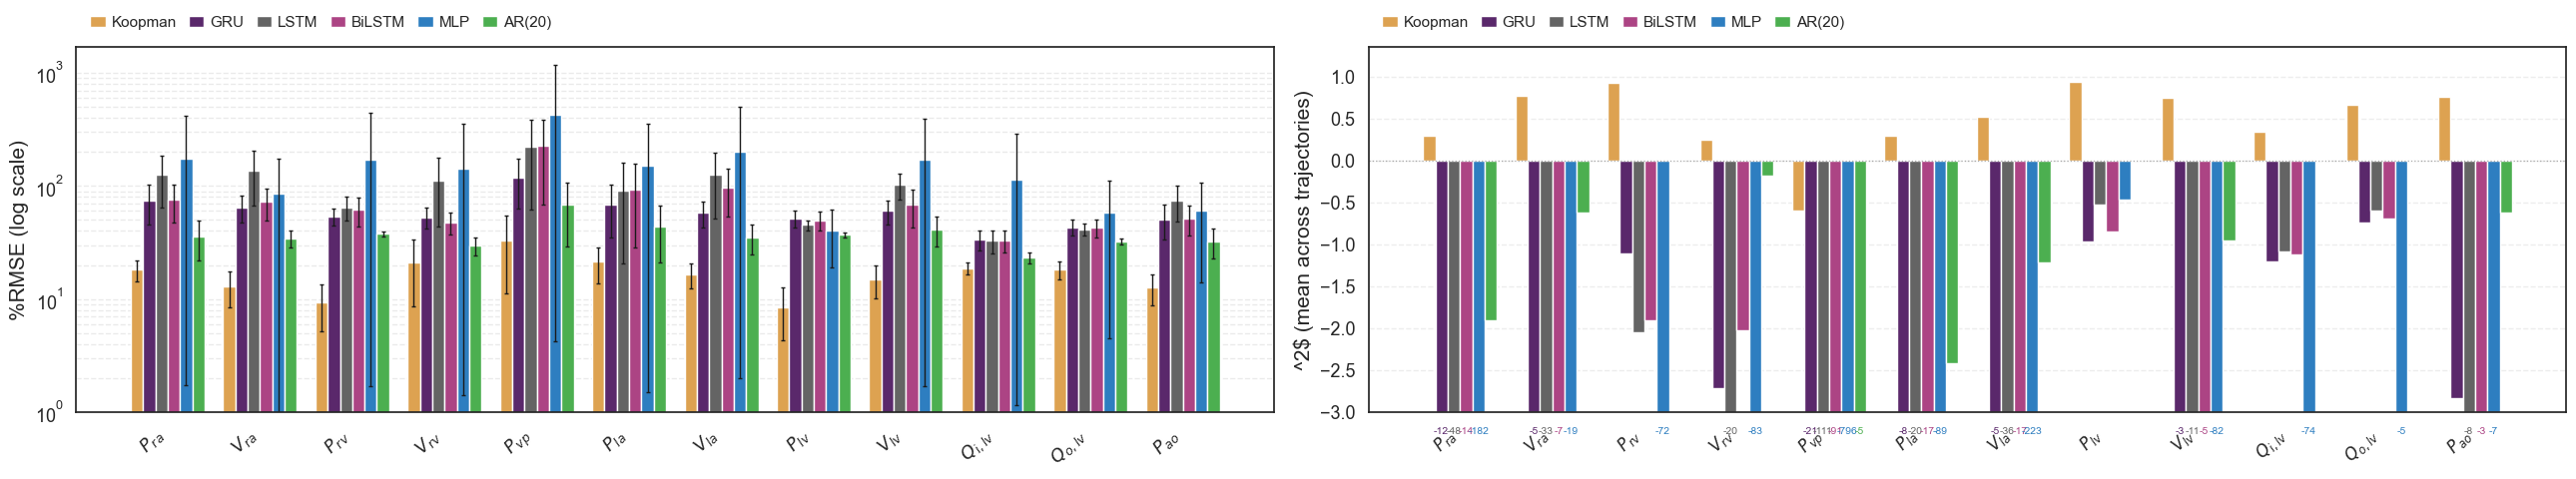

In [12]:
# ── Supplementary Figure: Full per-signal comparison — all signals, all models ─
# Panel 1: %RMSE per signal (all signals, log scale)
# Panel 2: R² per signal   (all signals)
# Requires: means, stds, r2_sig_all, ylab, models_all, custom_palette, R2_CLIP

_x_all   = np.arange(len(ylab))
_w_all   = 0.8 / len(models_all)
_sig_all = list(range(len(ylab)))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(26, 5))
plt.subplots_adjust(wspace=0.3)
plt.rcParams['axes.grid'] = False

# ── Panel A: %RMSE — all signals ──────────────────────────────────────────────
for i, m in enumerate(models_all):
    yerr_lo = np.clip(stds[i], 0, means[i] * 0.99)
    yerr_hi = stds[i]
    axA.bar(_x_all + i * _w_all, means[i], _w_all,
            yerr=[yerr_lo, yerr_hi], capsize=2,
            label=m, color=custom_palette[i],
            error_kw={'elinewidth': 1, 'capsize': 1.5})

axA.set_yscale('log')
axA.set_ylim(bottom=1)
axA.set_xticks(_x_all + _w_all * (len(models_all) - 1) / 2)
axA.set_xticklabels(ylab, rotation=45, ha='right', fontsize=12)
axA.set_ylabel('%RMSE (log scale)', fontsize=15)
axA.tick_params(labelsize=13)
axA.yaxis.grid(True, which='both', linestyle='--', alpha=0.4)
axA.set_axisbelow(True)
axA.legend(fontsize=11, loc='lower left', bbox_to_anchor=(0.0, 1.01),
           ncol=len(models_all), handlelength=1.0, handletextpad=0.4,
           columnspacing=0.8, frameon=False)

# ── Panel B: R² — all signals ─────────────────────────────────────────────────
for i, m in enumerate(models_all):
    r2s    = r2_sig_all[m][_sig_all]
    r2s_cl = np.clip(r2s, R2_CLIP, 1.05)
    axB.bar(_x_all + i * _w_all, r2s_cl, _w_all,
            color=custom_palette[i], label=m)
    for j, val in enumerate(r2s):
        bar_x = _x_all[j] + i * _w_all
        if val < R2_CLIP:
            axB.plot(bar_x, R2_CLIP + 0.08, 'v',
                     color=custom_palette[i], markersize=5, zorder=5, clip_on=False)
            axB.text(bar_x, R2_CLIP - 0.18, f'{val:.0f}',
                     ha='center', va='top', fontsize=7.5,
                     color=custom_palette[i], clip_on=False)

axB.axhline(0, color='#888888', lw=0.9, ls=':', alpha=0.7)
axB.set_ylim(R2_CLIP, 1.35)
axB.set_xticks(_x_all + _w_all * (len(models_all) - 1) / 2)
axB.set_xticklabels(ylab, rotation=45, ha='right', fontsize=12)
axB.tick_params(axis='y', labelsize=13)
axB.tick_params(axis='x', labelsize=12)
axB.set_ylabel(r'^2$ (mean across trajectories)', fontsize=15)
axB.yaxis.grid(True, linestyle='--', alpha=0.35)
axB.set_axisbelow(True)
axB.legend(fontsize=11, loc='lower left', bbox_to_anchor=(0.0, 1.01),
           ncol=len(models_all), handlelength=1.0, handletextpad=0.4,
           columnspacing=0.8, frameon=False)

plt.tight_layout()
plt.savefig(results_base_path / 'figures/figureS_all_signals.svg', format='svg', bbox_inches='tight')
plt.show()

##### Table 5

In [13]:
# ── Table 5: Noise robustness summary — all architectures ────────────────────
# Requires `curve_data`, `models_all`, `x_labels` from Figure 6 cell.

_rows_pct, _rows_r2 = [], []

for _xi, _lab in enumerate(x_labels):
    _row_pct = {"SNR Level": _lab}
    _row_r2  = {"SNR Level": _lab}
    for _m in models_all:
        _pm, _pc, _rm, _rc = curve_data[_m]
        _row_pct[_m] = f"{_pm[_xi]:.1f} ± {_pc[_xi]:.1f}"
        _row_r2 [_m] = f"{_rm[_xi]:.2f} ± {_rc[_xi]:.2f}"
    _rows_pct.append(_row_pct)
    _rows_r2 .append(_row_r2)

df_t5_pct = pd.DataFrame(_rows_pct).set_index("SNR Level")
df_t5_r2  = pd.DataFrame(_rows_r2 ).set_index("SNR Level")

# Combine into one MultiIndex DataFrame for display
df_t5 = pd.concat(
    {"%RMSE (mean ± 95% CI)": df_t5_pct, "R² (mean ± 95% CI)": df_t5_r2},
    axis=0
)
df_t5.index.names = ["Metric", "SNR Level"]

print("Table 5: Noise Robustness under AWGN — %RMSE and R² for all architectures\n")
display(df_t5)

# ── LaTeX export ─────────────────────────────────────────────────────────────
_latex = df_t5.to_latex(
    caption=(
        r"Noise robustness of all architectures under additive white Gaussian noise "
        r"(AWGN) applied to the initial state. Models were not retrained. "
        r"Values are mean $\pm$ 95\% CI across $B=50$ test trajectories."
    ),
    label="tab:noise_robustness",
    escape=False,
    column_format="ll" + "r" * len(models_all),
)
_out_tex = results_base_path / "tables" / "table5_noise_robustness.tex"
_out_tex.parent.mkdir(exist_ok=True)
_out_tex.write_text(_latex)
print(f"\nLaTeX saved → {_out_tex}")


Table 5: Noise Robustness under AWGN — %RMSE and R² for all architectures



Koopman           GRU          LSTM  \
Metric                SNR Level                                             
%RMSE (mean ± 95% CI) Clean        17.5 ± 1.5    60.9 ± 3.2   96.8 ± 11.1   
                      30 dB        19.8 ± 1.8    61.8 ± 3.4  106.2 ± 11.0   
                      20 dB        22.1 ± 2.1    60.4 ± 3.3  100.4 ± 10.5   
                      10 dB        30.9 ± 2.8    61.1 ± 3.4  111.6 ± 10.4   
                      5 dB         41.7 ± 2.9    62.2 ± 3.3  105.2 ± 11.9   
R² (mean ± 95% CI)    Clean       0.69 ± 0.03  -0.34 ± 0.07  -0.57 ± 0.11   
                      30 dB       0.60 ± 0.04  -0.32 ± 0.07  -0.64 ± 0.11   
                      20 dB       0.53 ± 0.06  -0.27 ± 0.08  -0.64 ± 0.10   
                      10 dB       0.28 ± 0.10  -0.39 ± 0.08  -0.71 ± 0.11   
                      5 dB       -0.07 ± 0.12  -0.42 ± 0.07  -0.64 ± 0.09   

                                       BiLSTM             MLP          AR(20)  
Metric                SNR Level                                                
%RMSE (mean ± 95% CI) Clean        77.2 ± 7.6    132.8 ± 55.2      34.5 ± 1.1  
                      30 dB        76.6 ± 7.8    102.5 ± 49.9    204.2 ± 45.2  
                      20 dB        79.8 ± 7.0    131.2 ± 57.7   492.0 ± 118.5  
                      10 dB        82.9 ± 6.7    220.2 ± 68.4  1931.2 ± 561.9  
                      5 dB         84.4 ± 7.6    264.7 ± 81.9  2966.8 ± 854.2  
R² (mean ± 95% CI)    Clean      -0.26 ± 0.07  -17.73 ± 10.46     0.33 ± 0.01  
                      30 dB      -0.22 ± 0.06   -12.73 ± 9.38     0.17 ± 0.05  
                      20 dB      -0.29 ± 0.07  -16.99 ± 10.16    -0.97 ± 0.59  
                      10 dB      -0.38 ± 0.07  -37.14 ± 15.97   -16.06 ± 7.25  
                      5 dB       -0.37 ± 0.07  -42.47 ± 17.48  -40.25 ± 12.78


LaTeX saved → ..\results\tables\table5_noise_robustness.tex


##### Table 3

In [14]:
display(df_traj)
alpha = 0.05

# Use results_all (includes MLP and AR(20)); fall back to pct_per_traj_flat for pkl models
def _get_pct_traj(res):
    if 'pct_per_traj_ps' in res:
        return res['pct_per_traj_ps']
    return res['pct_per_traj_flat']

model_names = list(results_all.keys())
data = [_get_pct_traj(results_all[mdl]) for mdl in model_names]

print("\n=== Statistical Testing for %RMSE ===")

# 1) Test for normality
norm_ps = [shapiro(d).pvalue for d in data]
print("Normality p-values:", dict(zip(model_names, norm_ps)))
all_normal = all(p > alpha for p in norm_ps)

# 2) Global test
if all_normal:
    stat, pval = f_oneway(*data)
    print(f"ANOVA: F = {stat:.3f}, p = {pval:.3f}")
else:
    stat, pval = kruskal(*data)
    print(f"Kruskal–Wallis: H = {stat:.3f}, p = {pval:.3f}")

# 3) Pairwise comparisons with Bonferroni correction
significant_models = set()
ncomp = len(data) * (len(data) - 1) / 2

for i, j in combinations(range(len(data)), 2):
    if all_normal:
        stat, p = ttest_ind(data[i], data[j])
    else:
        stat, p = mannwhitneyu(data[i], data[j], alternative='two-sided')

    adj_p = min(p * ncomp, 1.0)
    print(f"{model_names[i]} vs {model_names[j]}: p = {p:.3f}, p_adj = {adj_p:.3f}")

    if adj_p < alpha:
        # Mark the better (lower RMSE) model
        better = model_names[i] if np.mean(data[i]) < np.mean(data[j]) else model_names[j]
        significant_models.add(better)


,Koopman,GRU,LSTM,BiLSTM,MLP,AR(20)
Metric,,,,,,
R²,0.71,-1.46,-6.50,-2.68,-19.05,0.32
%RMSE (mean ± CI),17.1 ± 1.2%,60.9 ± 3.2%,97.8 ± 10.9%,76.4 ± 7.7%,149.2 ± 58.0%,37.6 ± 1.7%
Inference Time (s),0.005,0.640,0.758,1.582,0.166,0.008
Speedup,379.2x,3.2x,2.7x,1.3x,12.3x,262.3x
Parameter Count,"17,239,600","814,092","1,083,404","2,166,796","269,324",240
Training Time (min),47,289,312,401,9,<1



=== Statistical Testing for %RMSE ===
Normality p-values: {'Koopman': np.float64(2.0107090345501128e-06), 'GRU': np.float64(0.014057656956191005), 'LSTM': np.float64(0.03818982088582554), 'BiLSTM': np.float64(0.0011594664103967939), 'MLP': np.float64(3.12034881901185e-10), 'AR(20)': np.float64(0.0007988600212987777)}
Kruskal–Wallis: H = 199.304, p = 0.000
Koopman vs GRU: p = 0.000, p_adj = 0.000
Koopman vs LSTM: p = 0.000, p_adj = 0.000
Koopman vs BiLSTM: p = 0.000, p_adj = 0.000
Koopman vs MLP: p = 0.000, p_adj = 0.000
Koopman vs AR(20): p = 0.000, p_adj = 0.000
GRU vs LSTM: p = 0.000, p_adj = 0.000
GRU vs BiLSTM: p = 0.003, p_adj = 0.046
GRU vs MLP: p = 0.007, p_adj = 0.107
GRU vs AR(20): p = 0.000, p_adj = 0.000
LSTM vs BiLSTM: p = 0.005, p_adj = 0.078
LSTM vs MLP: p = 0.000, p_adj = 0.004
LSTM vs AR(20): p = 0.000, p_adj = 0.000
BiLSTM vs MLP: p = 0.002, p_adj = 0.024
BiLSTM vs AR(20): p = 0.000, p_adj = 0.000
MLP vs AR(20): p = 0.001, p_adj = 0.013


##### Table 4

In [15]:
def _build_per_signal_stats(true_phys, pred_phys):
    """Compute per-signal summary stats (shape D,) matching pkl result dict keys."""
    n_, T_, D_ = true_phys.shape
    # Per-trajectory, per-signal RMSE and %RMSE
    rmse_traj = np.sqrt(((true_phys - pred_phys) ** 2).mean(axis=1))   # (n, D)
    ptp_traj  = np.ptp(true_phys, axis=1) + 1e-8                        # (n, D)
    pct_traj  = 100.0 * rmse_traj / ptp_traj                            # (n, D)
    # Per-trajectory, per-signal R²
    r2_traj = np.zeros((n_, D_))
    for _d in range(D_):
        for _i in range(n_):
            t_ = true_phys[_i, :, _d]
            p_ = pred_phys[_i, :, _d]
            ss_res = ((t_ - p_) ** 2).sum()
            ss_tot = ((t_ - t_.mean()) ** 2).sum() + 1e-8
            r2_traj[_i, _d] = 1.0 - ss_res / ss_tot
    # Bland-Altman bias & LoA per signal
    diff     = pred_phys - true_phys            # (n, T, D)
    bias     = diff.mean(axis=(0, 1))           # (D,)
    loa_std  = diff.std(axis=(0, 1))            # (D,)
    ci95 = lambda x: 1.96 * x.std(axis=0, ddof=1) / np.sqrt(n_)
    return {
        'rmse_mean':  rmse_traj.mean(axis=0),
        'rmse_ci':    ci95(rmse_traj),
        'pct_mean':   pct_traj.mean(axis=0),
        'pct_ci':     ci95(pct_traj),
        'r2_mean':    r2_traj.mean(axis=0),
        'r2_ci':      ci95(r2_traj),
        'bias_mean':  bias,
        'loa_lower':  bias - 1.96 * loa_std,
        'loa_upper':  bias + 1.96 * loa_std,
    }

# Build extended results dict: original pkl models + MLP + AR(20)
results_extended = {
    **{m: results[m] for m in results},          # Koopman, GRU, LSTM, BiLSTM (pkl keys)
    'MLP':    _build_per_signal_stats(true, pred['MLP']),
    'AR(20)': _build_per_signal_stats(true, pred['AR(20)']),
}

cols = ['RMSE ± CI', '%RMSE ± CI', 'R² ± CI', 'Bias ± LoA']

for mdl in results_extended:
    r = results_extended[mdl]
    df = pd.DataFrame([
        (f"{a:.1f} ± {b:.1f}", f"{c:.1f}% ± {d:.1f}%", f"{e:.2f} ± {f:.2f}", f"{g:.1f} ± [{h:.1f}, {i:.1f}]")
        for a, b, c, d, e, f, g, h, i in zip(
            r['rmse_mean'], r['rmse_ci'], r['pct_mean'], r['pct_ci'],
            r['r2_mean'], r['r2_ci'], r['bias_mean'], r['loa_lower'], r['loa_upper']
        )
    ], index=[y.strip('$') for y in ylab], columns=cols)

    print(f"{mdl}:")
    display(df)
    print()


Koopman:


,RMSE ± CI,%RMSE ± CI,R² ± CI,Bias ± LoA
P_{ra},0.7 ± 0.0,18.1% ± 1.1%,0.30 ± 0.08,"0.1 ± [-1.3, 1.5]"
V_{ra},6.2 ± 0.6,13.0% ± 1.3%,0.77 ± 0.04,"-0.1 ± [-11.6, 11.3]"
P_{rv},2.8 ± 0.3,9.3% ± 1.1%,0.93 ± 0.02,"-0.1 ± [-5.5, 5.3]"
V_{rv},19.7 ± 2.8,21.0% ± 3.5%,0.25 ± 0.23,"8.3 ± [-21.4, 38.0]"
P_{vp},1.4 ± 0.2,32.8% ± 6.0%,-0.60 ± 0.85,"-0.2 ± [-2.3, 1.8]"
P_{la},1.8 ± 0.2,21.3% ± 2.1%,0.29 ± 0.13,"0.1 ± [-3.0, 3.2]"
V_{la},6.6 ± 0.8,16.5% ± 1.2%,0.52 ± 0.06,"-0.6 ± [-11.7, 10.6]"
P_{lv},10.3 ± 1.6,8.5% ± 1.2%,0.94 ± 0.02,"0.3 ± [-19.5, 20.0]"
V_{lv},12.9 ± 1.1,14.9% ± 1.4%,0.74 ± 0.05,"2.5 ± [-19.1, 24.0]"
"Q_{i,lv}",97.1 ± 6.9,18.6% ± 0.6%,0.35 ± 0.05,"5.6 ± [-183.0, 194.2]"



GRU:


,RMSE ± CI,%RMSE ± CI,R² ± CI,Bias ± LoA
P_{ra},2.8 ± 0.2,74.2% ± 8.0%,-12.17 ± 2.93,"1.0 ± [-3.8, 5.7]"
V_{ra},29.4 ± 1.4,64.2% ± 4.8%,-5.09 ± 1.09,"11.4 ± [-37.5, 60.4]"
P_{rv},16.8 ± 0.5,54.0% ± 2.5%,-1.08 ± 0.20,"-0.3 ± [-32.3, 31.6]"
V_{rv},49.4 ± 1.8,53.1% ± 3.2%,-2.78 ± 0.32,"-5.6 ± [-97.5, 86.4]"
P_{vp},5.0 ± 0.4,119.3% ± 15.7%,-18.89 ± 5.76,"-0.2 ± [-8.1, 7.7]"
P_{la},5.8 ± 0.4,68.7% ± 9.5%,-7.11 ± 2.34,"0.2 ± [-9.5, 9.8]"
V_{la},22.0 ± 1.3,57.7% ± 4.2%,-4.88 ± 0.81,"2.8 ± [-33.4, 39.0]"
P_{lv},60.6 ± 2.8,52.0% ± 2.6%,-1.04 ± 0.21,"-1.5 ± [-115.8, 112.9]"
V_{lv},51.2 ± 3.3,60.1% ± 4.0%,-3.09 ± 0.56,"2.3 ± [-85.1, 89.7]"
"Q_{i,lv}",177.0 ± 4.8,33.5% ± 1.8%,-1.11 ± 0.13,"-10.9 ± [-353.0, 331.2]"



LSTM:


...

,RMSE ± CI,%RMSE ± CI,R² ± CI,Bias ± LoA
P_{ra},3.0 ± 0.3,75.3% ± 7.8%,-12.33 ± 2.63,"-0.5 ± [-5.6, 4.6]"
V_{ra},33.5 ± 3.1,72.1% ± 6.4%,-6.43 ± 1.24,"-2.6 ± [-62.2, 57.0]"
P_{rv},19.1 ± 1.2,61.6% ± 5.0%,-1.86 ± 0.49,"-3.7 ± [-38.9, 31.6]"
V_{rv},44.2 ± 1.9,47.4% ± 3.0%,-2.02 ± 0.29,"-3.5 ± [-85.8, 78.8]"
P_{vp},8.8 ± 1.2,225.5% ± 44.0%,-90.82 ± 40.97,"3.7 ± [-8.8, 16.2]"
P_{la},7.4 ± 0.6,92.5% ± 17.9%,-16.22 ± 7.14,"1.4 ± [-10.6, 13.3]"
V_{la},36.0 ± 3.2,97.7% ± 12.3%,-18.26 ± 5.28,"13.2 ± [-42.9, 69.2]"
P_{lv},58.2 ± 3.1,49.9% ± 2.6%,-0.87 ± 0.18,"-8.1 ± [-119.5, 103.2]"
V_{lv},57.8 ± 5.7,68.1% ± 7.0%,-4.58 ± 1.20,"3.8 ± [-96.4, 104.0]"
"Q_{i,lv}",173.0 ± 5.9,32.8% ± 2.0%,-1.03 ± 0.15,"-16.2 ± [-351.2, 318.7]"



MLP:


,RMSE ± CI,%RMSE ± CI,R² ± CI,Bias ± LoA
P_{ra},7.0 ± 2.7,174.3% ± 68.5%,-182.46 ± 108.12,"-4.0 ± [-26.0, 18.0]"
V_{ra},41.1 ± 12.1,86.2% ± 24.7%,-19.48 ± 9.95,"-16.6 ± [-128.9, 95.7]"
P_{rv},51.5 ± 22.9,169.3% ± 75.9%,-72.04 ± 41.42,"-37.2 ± [-211.9, 137.5]"
V_{rv},138.7 ± 56.8,142.2% ± 59.2%,-82.74 ± 44.93,"88.7 ± [-360.6, 538.0]"
P_{vp},16.4 ± 6.6,424.0% ± 210.6%,-795.76 ± 702.10,"9.9 ± [-43.2, 62.9]"
P_{la},10.7 ± 3.3,150.0% ± 56.7%,-88.52 ± 51.99,"5.0 ± [-24.7, 34.8]"
V_{la},73.0 ± 30.0,199.9% ± 85.5%,-222.84 ± 123.49,"47.6 ± [-188.9, 284.1]"
P_{lv},48.5 ± 7.9,40.2% ± 5.9%,-0.47 ± 0.42,"-15.1 ± [-120.8, 90.7]"
V_{lv},153.4 ± 56.7,171.1% ± 62.2%,-81.62 ± 44.19,"76.9 ± [-397.4, 551.2]"
"Q_{i,lv}",554.4 ± 234.0,114.6% ± 49.6%,-74.32 ± 42.11,"-396.3 ± [-2201.9, 1409.3]"



AR(20):


,RMSE ± CI,%RMSE ± CI,R² ± CI,Bias ± LoA
P_{ra},1.4 ± 0.1,35.9% ± 3.9%,-1.90 ± 0.57,"-0.2 ± [-3.1, 2.7]"
V_{ra},16.3 ± 0.9,34.6% ± 1.7%,-0.62 ± 0.18,"-1.2 ± [-33.7, 31.3]"
P_{rv},11.7 ± 0.5,37.7% ± 0.5%,0.01 ± 0.00,"0.2 ± [-23.1, 23.5]"
V_{rv},28.1 ± 1.0,29.8% ± 1.5%,-0.18 ± 0.09,"2.2 ± [-53.1, 57.5]"
P_{vp},3.2 ± 0.5,68.0% ± 10.8%,-5.32 ± 2.46,"-0.9 ± [-8.0, 6.3]"
P_{la},3.5 ± 0.4,44.1% ± 6.4%,-2.42 ± 0.99,"0.7 ± [-6.5, 7.9]"
V_{la},13.5 ± 1.3,35.2% ± 3.0%,-1.22 ± 0.35,"2.5 ± [-25.1, 30.1]"
P_{lv},44.1 ± 1.7,37.0% ± 0.5%,0.01 ± 0.01,"0.5 ± [-86.7, 87.8]"
V_{lv},35.6 ± 2.6,41.2% ± 3.3%,-0.96 ± 0.33,"2.7 ± [-69.2, 74.5]"
"Q_{i,lv}",119.1 ± 5.3,23.2% ± 0.8%,0.01 ± 0.00,"0.4 ± [-235.9, 236.8]"


##### Figure S1

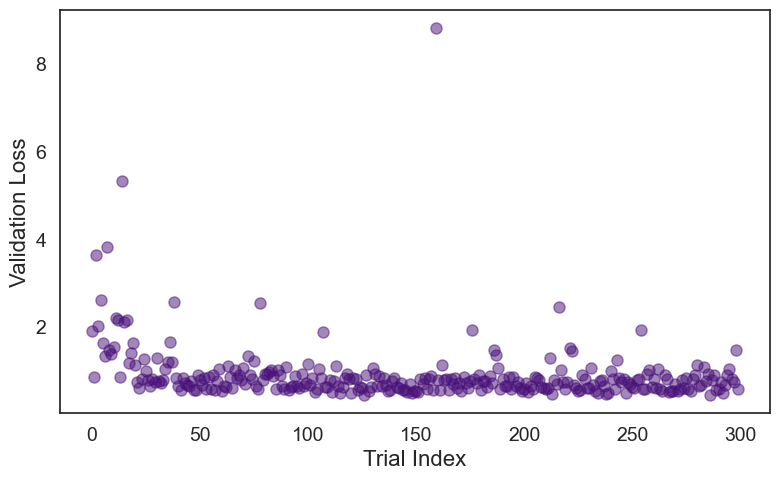

In [16]:
df = pd.read_csv(results_base_path / "optuna_runs" / "koopman_hyperparam_search_20250713_193701.csv")
#df_complete = df[df['State'] == 'COMPLETE'].copy()
df_complete = df.copy()  # Use all trials for plotting
df_complete.reset_index(drop=True, inplace=True)

plt.figure(figsize=(8, 5))
plt.plot( df_complete.index, df_complete['Value'], linestyle='None', marker='o', label='Validation Loss', markersize=8, alpha=0.5, color="#481078")
plt.grid(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Trial Index", fontsize=16)
plt.ylabel("Validation Loss", fontsize=16)
plt.tight_layout()
plt.savefig(results_base_path / "figures" / "supplementary_figure1.svg", format='svg')
plt.show()

##### Figure S2

C:\Users\MaxHaberbusch\AppData\Local\Temp\ipykernel_33180\499339585.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Sensitivity (std of grouped mean)', y='Hyperparameter', palette='plasma_r')


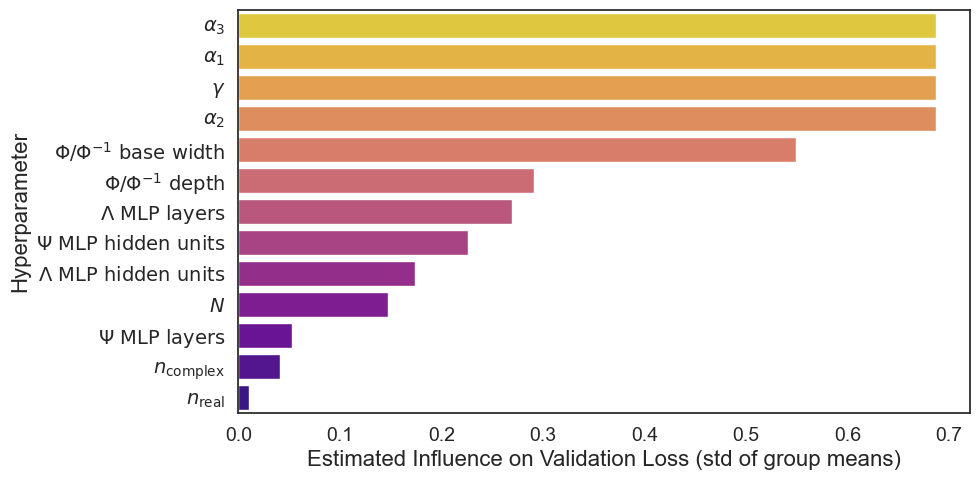

In [17]:
param_cols = [col for col in df_complete.columns if col.startswith("Param ")]
param_importance = {}
for col in param_cols:
    groups = df_complete.groupby(col)['Value']
    group_means = groups.mean()
    importance = group_means.std()  # you can use variance or range (np.ptp) if preferred
    param_importance[col] = importance

importance_df = pd.DataFrame({
    'Hyperparameter': list(param_importance.keys()),
    'Sensitivity (std of grouped mean)': list(param_importance.values())
}).sort_values(by='Sensitivity (std of grouped mean)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Sensitivity (std of grouped mean)', y='Hyperparameter', palette='plasma_r')
plt.xlabel('Estimated Influence on Validation Loss (std of group means)', fontsize=16)
plt.ylabel('Hyperparameter', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Set custom labels for the parameters so they are consistent with the paper
param_labels = [
    r'$\alpha_3$',
    r'$\alpha_1$',
    r'$\gamma$',
    r'$\alpha_2$',
    r'$\Phi/\Phi^{-1}\ \text{base width}$',
    r'$\Phi/\Phi^{-1}\ \text{depth}$',
    r'$\Lambda\ \text{MLP layers}$',
    r'$\Psi\ \text{MLP hidden units}$',
    r'$\Lambda\ \text{MLP hidden units}$',
    r'$N$',
    r'$\Psi\ \text{MLP layers}$',
    r'$n_{\text{complex}}$',
    r'$n_{\text{real}}$',
]

# set custom labels
plt.yticks(ticks=range(len(param_labels)), labels=param_labels, fontsize=14)
plt.tight_layout()
plt.savefig(results_base_path / "figures" / "supplementary_figure2.svg")
plt.show()


##### Figure S3

In [18]:
top5_params = importance_df['Hyperparameter'].head(5).tolist()
selected_dims = top5_params + ['Value']
df_plot = df_complete[selected_dims].copy()

fig = px.parallel_coordinates(
    df_plot,
    dimensions=selected_dims,
    color='Value',
    color_continuous_scale='plasma',
    range_color=[df_complete['Value'].min(), df_complete['Value'].max()],
    width=1800,
    height=600,
    # Set custom labels for the parameters so they are consistent with the paper
    labels = {
        'Param enc_start': 'Φ / Φ⁻¹ based width',
        'Param L2_lam': 'α₃',
        'Param recon_lam': 'α₁',
        'Param Linf_lam': 'α₂',
        'Param control_gain': 'γ',
        'Value': 'Loss'
    },
)
fig.update_layout(
    font=dict(
        size=22,       # Base font size for labels, tick labels, and legend
        family="Arial",  # You can choose another font
    )
)

fig.write_image(results_base_path / "figures" / "supplementary_figure3.svg")
fig.show()

##### Figure S4

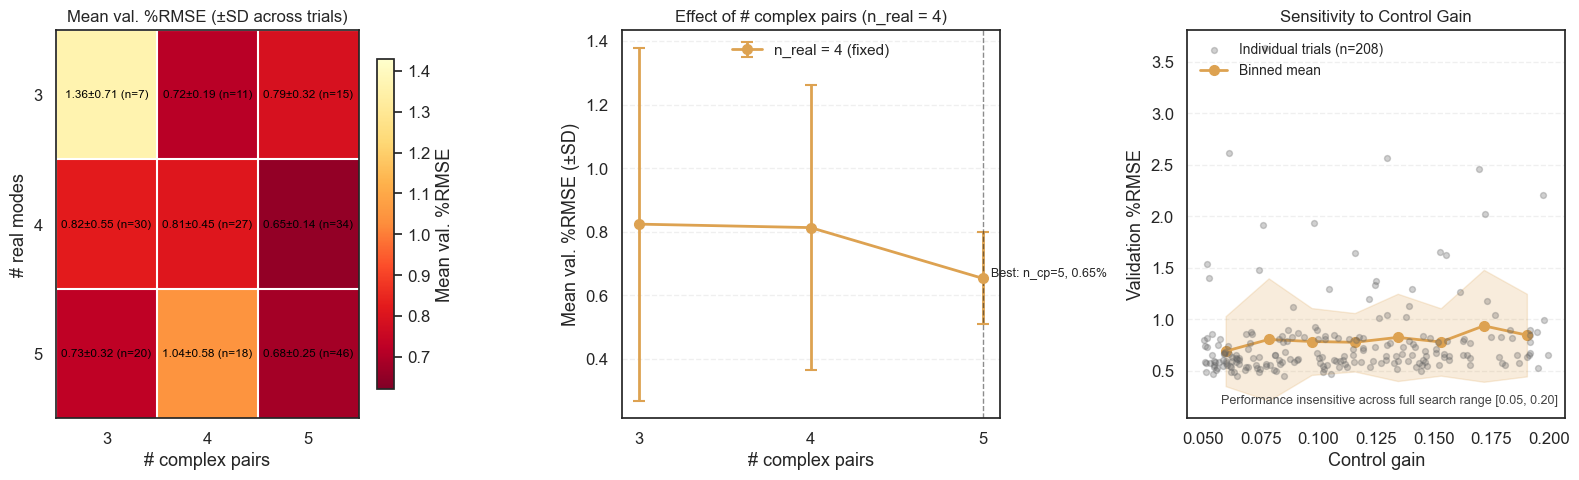

In [19]:
import json as _json

# Load latent ablation results
with open(results_base_path / 'latent_ablation.json') as _f:
    _la = _json.load(_f)

# Load Optuna CSV for control_gain sensitivity
_df_opt = pd.read_csv(results_base_path / 'optuna_runs' /
                      'koopman_hyperparam_search_20250713_193701.csv')
_df_cg  = _df_opt[_df_opt['State'] == 'COMPLETE'].copy()
_cg_vals  = _df_cg['Param control_gain'].values
_cg_vpct  = _df_cg['Value'].values

# Bin control_gain linearly into 8 bins
_cg_bins = np.linspace(_cg_vals.min() - 1e-4, _cg_vals.max() + 1e-4, 9)
_cg_idx  = np.digitize(_cg_vals, _cg_bins) - 1
_cg_bc, _cg_bm, _cg_bsd = [], [], []
for _b in range(len(_cg_bins) - 1):
    _mask = _cg_idx == _b
    if _mask.sum() == 0:
        continue
    _sub = _cg_vpct[_mask]
    _cg_bc.append(float((_cg_bins[_b] + _cg_bins[_b+1]) / 2))
    _cg_bm.append(float(_sub.mean()))
    _cg_bsd.append(float(_sub.std(ddof=1) if len(_sub) > 1 else 0.0))
_cg_bc  = np.array(_cg_bc)
_cg_bm  = np.array(_cg_bm)
_cg_bsd = np.array(_cg_bsd)

# Stable range: bins within 20% of global best binned mean

# Latent ablation matrices
_la_rows = _la['by_nc_nr']
_nc_vals = sorted(set(r['n_complex'] for r in _la_rows))
_nr_vals = sorted(set(r['n_real']    for r in _la_rows))
_hm    = np.full((len(_nr_vals), len(_nc_vals)), np.nan)
_hm_sd = np.full_like(_hm, np.nan)
_hm_n  = np.full_like(_hm, 0)
for _r in _la_rows:
    _i = _nr_vals.index(_r['n_real'])
    _j = _nc_vals.index(_r['n_complex'])
    _hm[_i, _j]    = _r['pct_mean']
    _hm_sd[_i, _j] = _r['pct_sd']
    _hm_n[_i, _j]  = _r['n_trials']

# Marginal: n_complex with n_real=4
_nc_marg = _la['by_n_complex_nr_fixed4']
_mx = [r['n_complex'] for r in _nc_marg]
_my = [r['pct_mean']  for r in _nc_marg]
_me = [r['pct_sd']    for r in _nc_marg]

_PAL = ['#dda251', '#5a286b', '#646464', '#ac4484']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plt.rcParams['axes.grid'] = False

# ── Panel A: heatmap mean +- SD per (n_complex, n_real) ──────────────────────
_ax = axes[0]
_im = _ax.imshow(_hm, aspect='auto', cmap='YlOrRd_r',
                 vmin=np.nanmin(_hm)*0.95, vmax=np.nanmax(_hm)*1.05)
_ax.set_xticks(range(len(_nc_vals)))
_ax.set_xticklabels([str(c) for c in _nc_vals], fontsize=12)
_ax.set_yticks(range(len(_nr_vals)))
_ax.set_yticklabels([str(r) for r in _nr_vals], fontsize=12)
_ax.set_xlabel('# complex pairs', fontsize=13)
_ax.set_ylabel('# real modes', fontsize=13)
_ax.set_title('Mean val. %RMSE (±SD across trials)', fontsize=12)
for _i in range(len(_nr_vals)):
    for _j in range(len(_nc_vals)):
        if not np.isnan(_hm[_i, _j]):
            _lbl = '{:.2f}±{:.2f} (n={:d})'.format(
                _hm[_i,_j], _hm_sd[_i,_j], int(_hm_n[_i,_j]))
            _ax.text(_j, _i, _lbl,
                     ha='center', va='center', fontsize=8.5, color='black')
fig.colorbar(_im, ax=_ax, shrink=0.85, label='Mean val. %RMSE')
_ax.set_xticks(np.arange(len(_nc_vals)) - 0.5, minor=True)
_ax.set_yticks(np.arange(len(_nr_vals)) - 0.5, minor=True)
_ax.grid(which='minor', color='white', linewidth=1.5)
_ax.tick_params(which='minor', bottom=False, left=False)

# ── Panel B: marginal n_complex (n_real=4 fixed) ─────────────────────────────
_ax2 = axes[1]
_ax2.errorbar(_mx, _my, yerr=_me, fmt='o-', color=_PAL[0],
              linewidth=2, markersize=7, capsize=4, capthick=1.5,
              label='n_real = 4 (fixed)')
_best_x = _mx[int(np.argmin(_my))]
_best_y = _my[int(np.argmin(_my))]
_ax2.axvline(_best_x, color='k', linestyle='--', linewidth=1, alpha=0.5)
_ax2.text(_best_x + 0.05, _best_y * 1.01,
          'Best: n_cp={}, {:.2f}%'.format(_best_x, _best_y), fontsize=9)
_ax2.set_xticks(_mx)
_ax2.set_xlabel('# complex pairs', fontsize=13)
_ax2.set_ylabel('Mean val. %RMSE (±SD)', fontsize=13)
_ax2.set_title('Effect of # complex pairs (n_real = 4)', fontsize=12)
_ax2.tick_params(labelsize=12)
_ax2.yaxis.grid(True, linestyle='--', alpha=0.3)
_ax2.set_axisbelow(True)
_ax2.legend(fontsize=11, frameon=False)

# ── Panel C: control gain sensitivity ────────────────────────────────────────
_ax3 = axes[2]
_ax3.scatter(_cg_vals, _cg_vpct, alpha=0.30, s=18, color=_PAL[2],
             label='Individual trials (n={})'.format(len(_cg_vals)), zorder=3)
_ax3.plot(_cg_bc, _cg_bm, 'o-', color=_PAL[0], linewidth=2, markersize=7,
          label='Binned mean')
_ax3.fill_between(_cg_bc, _cg_bm - _cg_bsd, _cg_bm + _cg_bsd,
                  alpha=0.2, color=_PAL[0])
_ax3.set_xlabel('Control gain', fontsize=13)
_ax3.set_ylabel('Validation %RMSE', fontsize=13)
_ax3.set_title('Sensitivity to Control Gain', fontsize=12)
_ax3.tick_params(labelsize=12)
_ax3.yaxis.grid(True, linestyle='--', alpha=0.3)
_ax3.set_axisbelow(True)
_ax3.legend(fontsize=10, frameon=False, loc='upper left')
_ax3.text(0.98, 0.03,
          'Performance insensitive across full search range [0.05, 0.20]',
          transform=_ax3.transAxes, ha='right', va='bottom',
          fontsize=9, color='#444444')

plt.tight_layout()
plt.savefig(results_base_path / 'figures' / 'figureS4.svg',
            format='svg', bbox_inches='tight')
plt.show()


##### Figure SX — Koopman Mode Analysis (Variance, Frequency, Ablation)

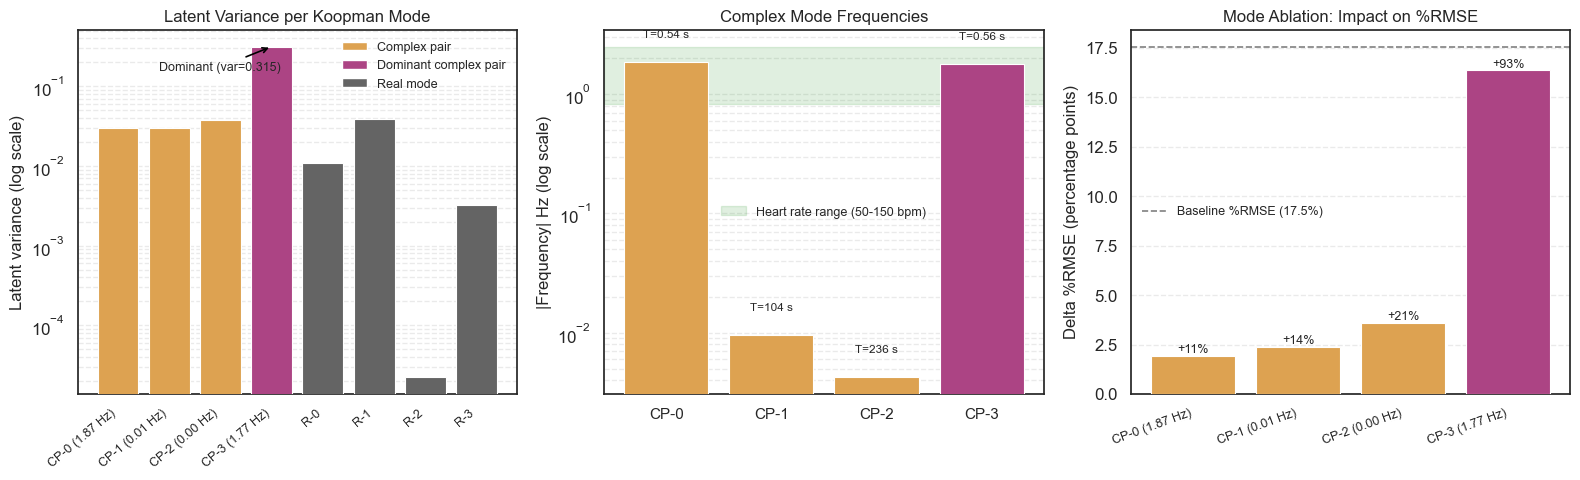

Saved -> ..\results\figures\figureSX_mode_analysis.svg
  Ablate CP-0: +1.93 pp (11.0% relative)
  Ablate CP-1: +2.39 pp (13.7% relative)
  Ablate CP-2: +3.61 pp (20.6% relative)
  Ablate CP-3: +16.38 pp (93.4% relative)


In [ ]:
import json as _json

with open(results_base_path / 'mode_frequencies.json') as _f:
    _mf = _json.load(_f)
with open(results_base_path / 'mode_ablation.json') as _f:
    _ma = _json.load(_f)

_modes  = _mf['modes']
_PAL    = ['#dda251', '#5a286b', '#646464', '#ac4484']
_C_COL  = _PAL[0]   # complex modes
_R_COL  = _PAL[2]   # real modes
_HL_COL = _PAL[3]   # dominant mode highlight

# ordered labels, variances, colours for all 12 latent dims
_labels, _variances, _colors = [], [], []
for _m in _modes:
    if _m['type'] == 'complex':
        _labels.append('CP-{} ({:.2f} Hz)'.format(_m['index'], abs(_m['f_hz'])))
        _variances.append(_m['latent_variance'])
        _colors.append(_HL_COL if _m['index'] == 3 else _C_COL)
    else:
        _labels.append('R-{}'.format(_m['index']))
        _variances.append(_m['latent_variance'])
        _colors.append(_R_COL)

_x = np.arange(len(_labels))

# ablation data
_abl       = sorted(_ma['ablation_results'], key=lambda r: r['mode_index'])
_abl_lbls  = ['CP-{} ({:.2f} Hz)'.format(r['mode_index'], abs(r['f_hz'])) for r in _abl]
_abl_delta = [r['pct_rmse_increase'] for r in _abl]
_abl_cols  = [_HL_COL if r['mode_index'] == 3 else _C_COL for r in _abl]
_baseline  = _ma['baseline_pct_rmse']

_fig, (_ax1, _ax2, _ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: latent variance per mode
_ax1.bar(_x, _variances, color=_colors, edgecolor='white', linewidth=0.8, zorder=3)
_ax1.set_yscale('log')
_ax1.set_xticks(_x)
_ax1.set_xticklabels(_labels, rotation=40, ha='right', fontsize=9)
_ax1.set_ylabel('Latent variance (log scale)', fontsize=12)
_ax1.set_title('Latent Variance per Koopman Mode', fontsize=12)
_ax1.yaxis.grid(True, which='both', linestyle='--', alpha=0.4)
_ax1.set_axisbelow(True)
_dom_i = _labels.index('CP-3 (1.77 Hz)')
_ax1.annotate(
    'Dominant (var={:.3f})'.format(_variances[_dom_i]),
    xy=(_dom_i, _variances[_dom_i]),
    xytext=(_dom_i - 2.2, _variances[_dom_i] * 0.5),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    fontsize=9)
from matplotlib.patches import Patch as _Patch
_ax1.legend(handles=[
    _Patch(facecolor=_C_COL, label='Complex pair'),
    _Patch(facecolor=_HL_COL, label='Dominant complex pair'),
    _Patch(facecolor=_R_COL,  label='Real mode'),
], fontsize=9, frameon=False)

# Panel B: |frequency| for complex modes
_cp  = [_m for _m in _modes if _m['type'] == 'complex']
_cpx = np.arange(len(_cp))
_ax2.bar(_cpx, [abs(_m['f_hz']) for _m in _cp],
         color=[_HL_COL if _m['index'] == 3 else _C_COL for _m in _cp],
         edgecolor='white', linewidth=0.8, zorder=3)
_ax2.set_yscale('log')
_ax2.axhspan(0.833, 2.5, alpha=0.12, color='green',
             label='Heart rate range (50-150 bpm)')
_ax2.set_xticks(_cpx)
_ax2.set_xticklabels(['CP-{}'.format(_m['index']) for _m in _cp], fontsize=11)
_ax2.set_ylabel('|Frequency| Hz (log scale)', fontsize=12)
_ax2.set_title('Complex Mode Frequencies', fontsize=12)
_ax2.yaxis.grid(True, which='both', linestyle='--', alpha=0.4)
_ax2.set_axisbelow(True)
_ax2.legend(fontsize=9, frameon=False)
for _xi, _m in zip(_cpx, _cp):
    _fabs = abs(_m['f_hz'])
    _lbl = 'T={:.2f} s'.format(_m['period_s']) if _fabs > 0.1 else 'T={:.0f} s'.format(_m['period_s'])
    _ax2.text(_xi, _fabs * 1.6, _lbl, ha='center', fontsize=8.5)

# Panel C: ablation delta %RMSE
_ax3.bar(np.arange(len(_abl)), _abl_delta, color=_abl_cols,
         edgecolor='white', linewidth=0.8, zorder=3)
_ax3.axhline(_baseline, color='grey', linestyle='--', linewidth=1.2,
             label='Baseline %RMSE ({:.1f}%)'.format(_baseline))
_ax3.set_xticks(np.arange(len(_abl)))
_ax3.set_xticklabels(_abl_lbls, rotation=20, ha='right', fontsize=9)
_ax3.set_ylabel('Delta %RMSE (percentage points)', fontsize=12)
_ax3.set_title('Mode Ablation: Impact on %RMSE', fontsize=12)
_ax3.yaxis.grid(True, linestyle='--', alpha=0.4)
_ax3.set_axisbelow(True)
_ax3.legend(fontsize=9, frameon=False)
for _xi, _r in zip(np.arange(len(_abl)), _abl):
    _rel = _r['pct_rmse_increase'] / _baseline * 100
    _ax3.text(_xi, _r['pct_rmse_increase'] + 0.15,
              '+{:.0f}%'.format(_rel), ha='center', fontsize=9)

plt.tight_layout()
_out = results_base_path / 'figures' / 'figureS6_mode_analysis.svg'
plt.savefig(_out, format='svg', bbox_inches='tight')
plt.savefig(str(_out).replace('.svg', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', _out)
for _r in _abl:
    print('  Ablate CP-{}: +{:.2f} pp ({:.1f}% relative)'.format(
        _r['mode_index'], _r['pct_rmse_increase'],
        _r['pct_rmse_increase'] / _baseline * 100))


##### Figure S5

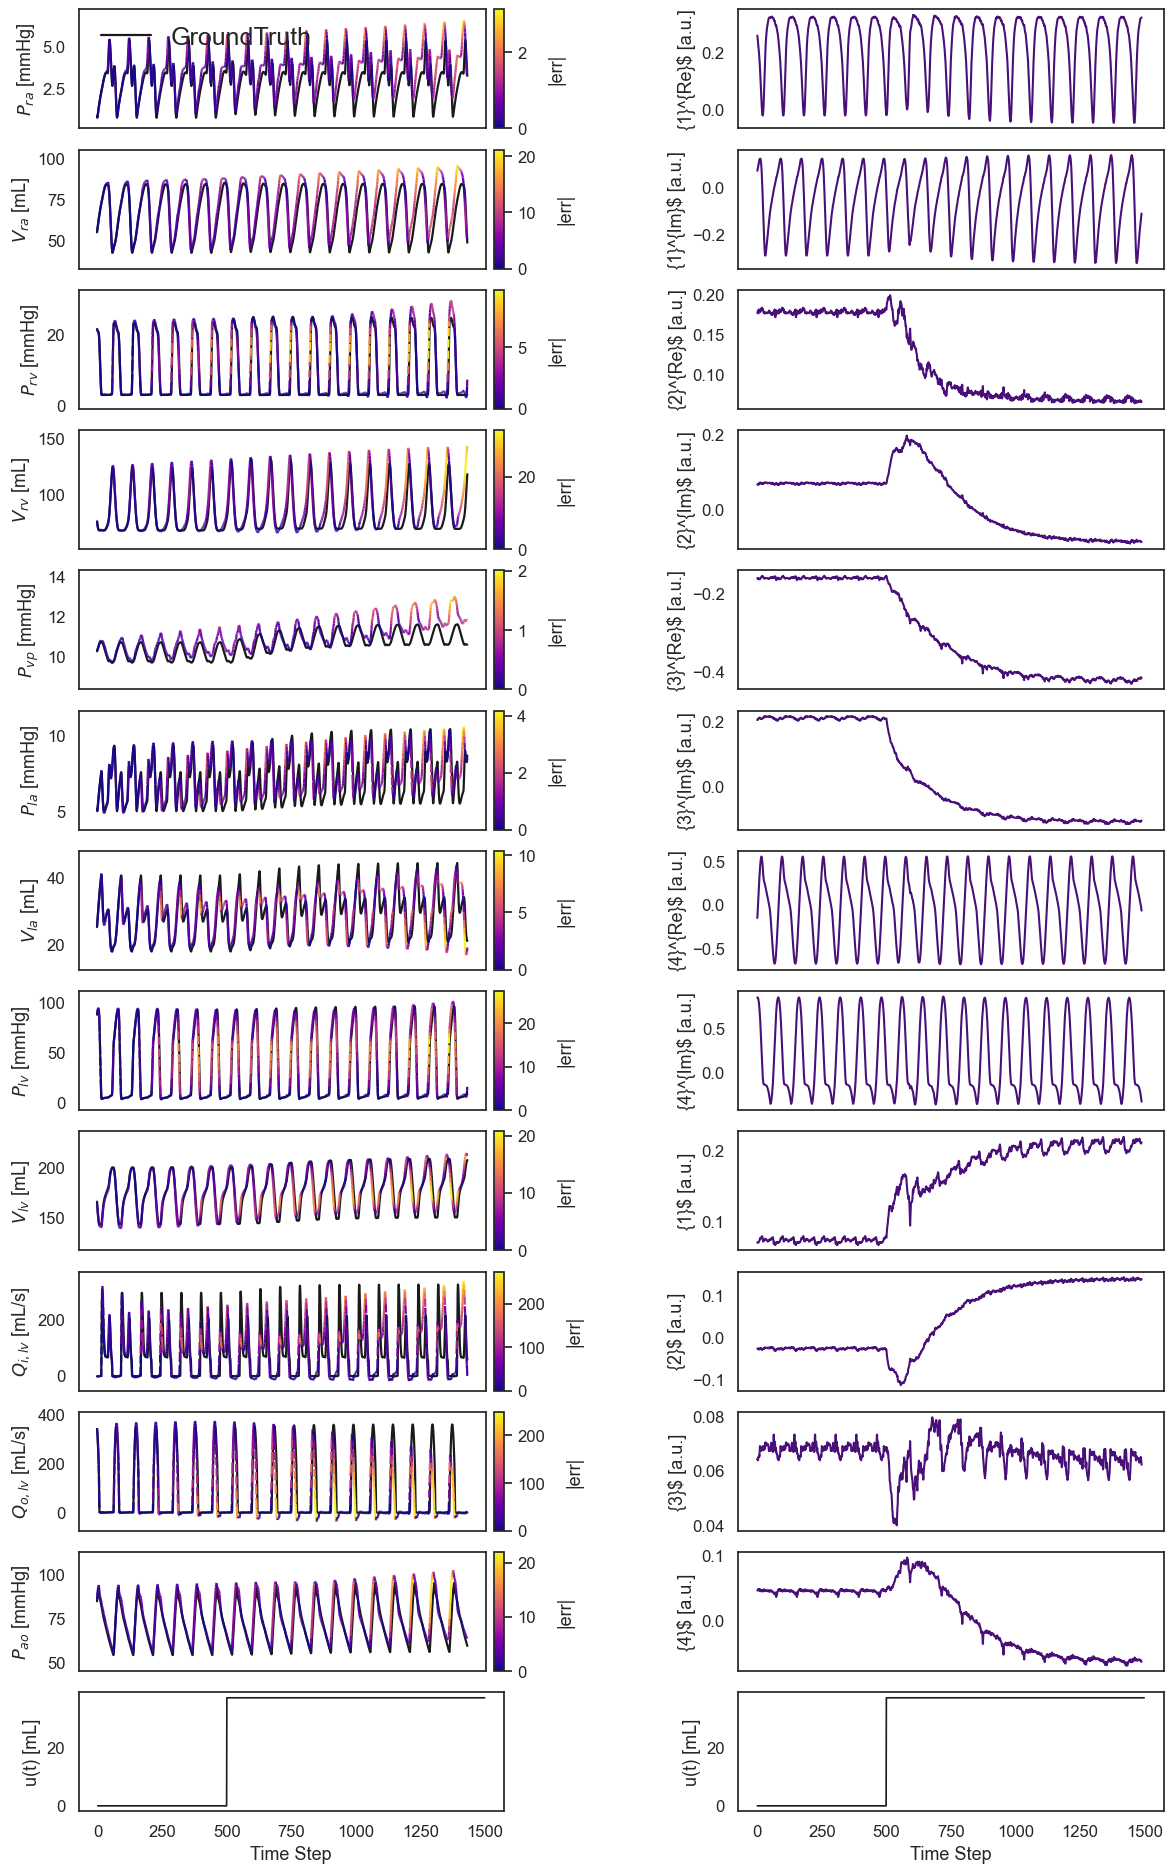

In [21]:
# Figure S4: Koopman — ALL 12 haemodynamic signals (left) + ALL 12 latent modes (right)
# Requires cell 9 (Figure 4a) to have run.

SIG_ALL = list(range(12))

# Build labels for all 12 latent modes in column order
_ncp = params["num_complex_pairs"]   # 4
_nr  = params["num_real"]            # 4
_mode_labels_all = []
for _k in range(1, _ncp + 1):
    _mode_labels_all.append(rf"{{{_k}}}^{{Re}}$ [a.u.]")
    _mode_labels_all.append(rf"{{{_k}}}^{{Im}}$ [a.u.]")
for _k in range(1, _nr + 1):
    _mode_labels_all.append(rf"{{{_k}}}$ [a.u.]")

n_rows = len(SIG_ALL) + 1   # 12 signals + control
fig, axes = plt.subplots(n_rows, 2,
                         figsize=(14, n_rows * 1.8),
                         sharex=True)
plt.subplots_adjust(hspace=0.18, wspace=0.55)

# Left column: all 12 physiological signals
for row, sig_i in enumerate(SIG_ALL):
    label = f"{ylab[sig_i]} [{units[sig_i]}]"
    nu.plot_signal_panel(axes[row, 0], y_true_all[:, sig_i], y_pred_all[:, sig_i],
                         cmap_err, ylabel=label, show_legend=(row == 0))

# Right column: all 12 latent modes (column order 0..11)
for col_i, mode_label in enumerate(_mode_labels_all):
    axes[col_i, 1].plot(range(len(yk_trimmed)), yk_trimmed[:, col_i],
                        linewidth=1.5, color="#481078")
    axes[col_i, 1].set_ylabel(mode_label)
    axes[col_i, 1].grid(False)

# Bottom row: control input on both columns
nu.plot_control_panel(axes[-1, 0], u_seq)
nu.plot_control_panel(axes[-1, 1], u_seq)

# Uniform font sizes
_LBL, _TICK = 13, 12
for _ax in axes.flat:
    _ax.yaxis.label.set_size(_LBL)
    _ax.xaxis.label.set_size(_LBL)
    _ax.tick_params(axis="both", labelsize=_TICK)
for _ax in fig.axes:
    if _ax not in list(axes.flat):   # colourbars
        _ax.tick_params(labelsize=_TICK)
        _ax.yaxis.label.set_size(_LBL)

plt.savefig(results_base_path / "figures" / "figureS5.svg",
            format="svg", bbox_inches="tight")
plt.show()


##### Supplementary Table S3 — Data Leakage Check

In [22]:
import json as _json

with open(results_base_path / 'lhs_distance_check.json') as _f:
    _lhs = _json.load(_f)

_rows = [
    ('Test vs. Train (nearest-neighbour)',
     _lhs['test_to_train_nn_distances']),
    ('Val vs. Train (nearest-neighbour)',
     _lhs['val_to_train_nn_distances']),
    ('Within Train (leave-one-out)',
     _lhs['within_train_nn_distances']),
]

_tbl = pd.DataFrame(
    [{
        'Comparison':        _label,
        'n':                 int(_s['n']),
        'Min':               round(_s['min'],  3),
        'Q25':               round(_s['q25'],  3),
        'Mean':              round(_s['mean'], 3),
        'SD':                round(_s['sd'],   3),
        'Q75':               round(_s['q75'],  3),
        'Max':               round(_s['max'],  3),
    } for _label, _s in _rows]
)

_tbl_out = results_base_path / 'table_S3_lhs_distances.csv'
_tbl.to_csv(_tbl_out, index=False)

_latex = _tbl.to_latex(
    index=False,
    caption=(
        'Nearest-neighbour distances in z-score-normalised 11-dimensional '
        'parameter space (Euclidean). '
        'All distances are well above zero, confirming absence of data leakage.'
    ),
    label='tab:lhs_distances',
    column_format='lrrrrrrrr',
    escape=False,
)
with open(results_base_path / 'table_S3_lhs_distances.tex', 'w') as _f:
    _f.write(_latex)

print('Supplementary Table S3: Nearest-Neighbour Distances in Parameter Space')
print('(all values in normalised units; n = number of query points)')
print()
display(_tbl.style
    .format({'Min': '{:.3f}', 'Q25': '{:.3f}', 'Mean': '{:.3f}',
             'SD': '{:.3f}', 'Q75': '{:.3f}', 'Max': '{:.3f}'})
    .set_caption('Table S3. Nearest-neighbour distances in normalised parameter space')
    .hide(axis='index')
)
print('Saved ->', _tbl_out)


Supplementary Table S3: Nearest-Neighbour Distances in Parameter Space
(all values in normalised units; n = number of query points)



Comparison,n,Min,Q25,Mean,SD,Q75,Max
Test vs. Train (nearest-neighbour),50,1.563,1.905,2.162,0.319,2.402,2.767
Val vs. Train (nearest-neighbour),50,1.404,1.971,2.193,0.315,2.353,2.828
Within Train (leave-one-out),400,1.234,1.947,2.168,0.331,2.391,3.048


Saved -> ..\results\table_S3_lhs_distances.csv


# ════════════════════════════════════════════════════
# Revision 2 (updated figures, panels & tables)
These cells run the reproducible standalone scripts under `scripts/revision2/`
(the single source of truth) and display each result inline.

In [ ]:
import os as _os, sys as _sys, subprocess as _sp, time as _time
from pathlib import Path as _Path
from IPython.display import Image as _Image, display as _display

_here = _Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "scripts" / "revision2" / "run_all.py").exists()), None)
assert REPO is not None, "Could not locate the repo root (scripts/revision2/run_all.py)"
REV2, FIGDIR, PY = REPO/"scripts"/"revision2", REPO/"results"/"figures", _sys.executable
print("Repo   :", REPO); print("Python :", PY)

def run_script(name):
    """Run a revision-2 script in a fresh process (Agg backend) and stream its output."""
    s = REV2 / name
    print(f"$ python {s.relative_to(REPO)}\n")
    r = _sp.run([PY, str(s)], cwd=str(REPO),
                env=dict(_os.environ, PYTHONIOENCODING="utf-8"),
                capture_output=True, text=True)
    if r.stdout: print(r.stdout)
    if r.returncode != 0:
        print("STDERR:\n", r.stderr); raise RuntimeError(f"{name} exited with code {r.returncode}")

def show(*pngs, width=1100):
    for p in pngs:
        fp = FIGDIR / p
        _display(_Image(filename=str(fp), width=width)) if fp.exists() else print("MISSING:", fp)


### 0. (Optional) Train the direct linear baselines — Task A
Expensive; only needs to run **once**. The cell runs it only if the pickles are missing.

In [ ]:
_need_a = not ((REPO/"results"/"dlinear"/"dlinear_postprocessing_results.pkl").exists()
                and (REPO/"results"/"nlinear"/"nlinear_postprocessing_results.pkl").exists())
if _need_a:
    print("DLinear/NLinear pickles missing -> running Task A (training)…"); run_script("task_a_dlinear_nlinear.py")
else:
    print("DLinear/NLinear pickles present -> skipping Task A (delete them to retrain).")


### 1. Tables 3–5, Figure 5, Figure 6 (+ Supplementary Figure S9)

In [ ]:
run_script("build_tables_figures.py")
show("figure5_rev2_comparison.png", "figure6_rev2_noise.png", "figureS9_comparison_full8.png")
print("Tables 3/4/5 -> results/revision2/table{3,4,5}_*.csv / .tex")


In [ ]:
run_script("regenerate_panels_a_gj.py")
print("Figure 5 (6-model main):"); show("figure5a_rev2.png", "figure5_panels_gj_rev2.png")
print("Figure S9 (full 8-model):"); show("figureS9a_full8.png", "figureS9_panels_gj_full8.png")


### 2. Supplementary figures S4, S6, S7, S8, S10

In [ ]:
run_script("task_b_gamma_sweep.py")
show("figureS_gamma_control_sweep.png")   # Figure S7


In [ ]:
run_script("task_d_realistic_streaming_noise.py")
show("figureS_realistic_streaming_noise.png")   # Figure S8


In [ ]:
run_script("task_f_clean_reanchoring.py")
show("figureS_clean_reanchoring.png")   # Figure S10


In [ ]:
run_script("figure_mode_analysis.py")
show("figureSX_mode_analysis.png")   # Figure S6


In [ ]:
run_script("figure_latent_hparam.py")
show("figureS4.png")   # Figure S4


### 3. Supplementary tables & exports (Table S4, mode-ablation)

In [ ]:
run_script("task_c_activation.py")   # Table S4 — control-net activation comparison


In [ ]:
run_script("task_e_mode_ablation_export.py")   # mode-ablation table -> results/revision2/table_mode_ablation.*


In [ ]:
print("Revision-2 figures currently on disk:\n")
for stem in ["figure5a_rev2","figure5_rev2_comparison","figure5_panels_gj_rev2","figure6_rev2_noise",
             "figureS4","figureSX_mode_analysis","figureS_gamma_control_sweep",
             "figureS_realistic_streaming_noise","figureS_clean_reanchoring",
             "figureS9a_full8","figureS9_comparison_full8","figureS9_panels_gj_full8"]:
    fp = FIGDIR / f"{stem}.png"
    tag = _time.strftime("%Y-%m-%d %H:%M", _time.localtime(fp.stat().st_mtime)) if fp.exists() else "MISSING"
    print(f"  {stem:38s}  {tag}")
